## Loading Libraries

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/jigsaw-unintended-bias-in-toxicity-classification/sample_submission.csv
/kaggle/input/competitions/jigsaw-unintended-bias-in-toxicity-classification/all_data.csv
/kaggle/input/competitions/jigsaw-unintended-bias-in-toxicity-classification/test_public_expanded.csv
/kaggle/input/competitions/jigsaw-unintended-bias-in-toxicity-classification/test_private_expanded.csv
/kaggle/input/competitions/jigsaw-unintended-bias-in-toxicity-classification/toxicity_individual_annotations.csv
/kaggle/input/competitions/jigsaw-unintended-bias-in-toxicity-classification/train.csv
/kaggle/input/competitions/jigsaw-unintended-bias-in-toxicity-classification/identity_individual_annotations.csv
/kaggle/input/competitions/jigsaw-unintended-bias-in-toxicity-classification/test.csv


In [2]:
!pip install torch scikit-learn sentence-transformers -q

In [3]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
from collections import OrderedDict
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, auc

device = "cuda" if torch.cuda.is_available() else "cpu"
display(f"device: {device}")

'device: cuda'

## Data prep

### Loading the Dataset

In [4]:
toxicity_train_path = "/kaggle/input/competitions/jigsaw-unintended-bias-in-toxicity-classification/train.csv"
temp_toxicity_train_df = pd.read_csv(toxicity_train_path, nrows=2, low_memory=True, memory_map=True)

In [5]:
mapdtype = {'int64': 'int32', 'float64':'float32'}
toxicity_dtypes = list(temp_toxicity_train_df.dtypes.apply(str).replace(mapdtype))
toxicity_dtypes = {key: value for (key, value) in enumerate(toxicity_dtypes)}

In [51]:
toxicity_train_df = pd.read_csv(toxicity_train_path, nrows=100000, low_memory=True, memory_map=True, dtype=toxicity_dtypes)

### Dataset Info

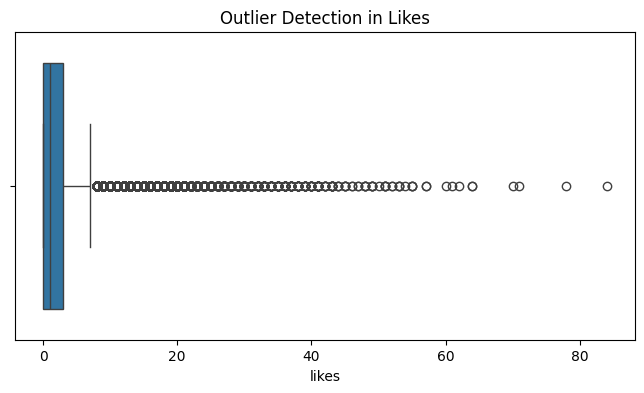

In [52]:
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.boxplot(x=toxicity_train_df['likes'])
plt.title('Outlier Detection in Likes')
plt.show()

In [53]:
filtered_toxicity_train_df = toxicity_train_df[(toxicity_train_df['likes'] < 10) & (toxicity_train_df['likes'] > 0)].copy()

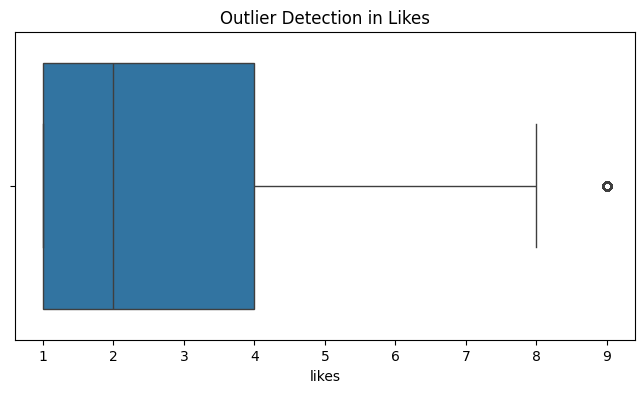

In [54]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=filtered_toxicity_train_df['likes'])
plt.title('Outlier Detection in Likes')
plt.show()

In [56]:
# 1. Separate the classes
toxic_df = toxicity_train_df[toxicity_train_df['target'] >= 0.5]
safe_df = toxicity_train_df[toxicity_train_df['target'] < 0.5]

# 2. Undersample the safe comments to match the number of toxic comments
safe_undersampled_df = safe_df.sample(n=len(toxic_df), random_state=42)

# 3. Recombine and shuffle
balanced_train_df = pd.concat([toxic_df, safe_undersampled_df]).sample(frac=1, random_state=42).reset_index(drop=True)

len(balanced_train_df)

13830

In [57]:
toxicity_valid_df = balanced_train_df[:1000]
toxicity_train_df = balanced_train_df[1001:]

In [12]:
toxicity_train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14597 entries, 2001 to 16597
Data columns (total 45 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   14597 non-null  int32  
 1   target                               14597 non-null  float32
 2   comment_text                         14597 non-null  object 
 3   severe_toxicity                      14597 non-null  float32
 4   obscene                              14597 non-null  float32
 5   identity_attack                      14597 non-null  float32
 6   insult                               14597 non-null  float32
 7   threat                               14597 non-null  float32
 8   asian                                3611 non-null   float32
 9   atheist                              3611 non-null   float32
 10  bisexual                             3611 non-null   float32
 11  black                    

In [13]:
toxicity_train_df.head()

,id,target,comment_text,severe_toxicity,obscene,identity_attack,insult,threat,asian,atheist,...,article_id,rating,funny,wow,sad,likes,disagree,sexual_explicit,identity_annotator_count,toxicity_annotator_count
2001,262379,1.000000,It appears Christgau has been reading some far...,0.0,0.000000,0.0,1.000000,0.0,NaN,NaN,...,54610,approved,0,0,0,2,0,0.0,0,4
2002,241026,1.000000,Dear world:\nJust a reminder that none of thes...,0.0,0.000000,0.0,1.000000,0.0,NaN,NaN,...,34702,approved,0,0,0,8,0,0.0,0,4
2003,335437,0.600000,"""Aside from starting the budget at a lower lev...",0.0,0.000000,0.2,0.600000,0.0,NaN,NaN,...,137867,approved,0,0,0,2,0,0.0,0,10
2004,425044,0.000000,Well said !,0.0,0.000000,0.0,0.000000,0.0,NaN,NaN,...,143451,approved,0,0,0,1,0,0.0,0,4
2005,473245,0.654545,"You don't count. Freddy, the arrogant, pompous...",0.0,0.072727,0.0,0.654545,0.0,0.0,0.0,...,145851,approved,0,0,0,1,0,0.0,4,55


### Sentence Transformer

In [14]:
embedding_model = SentenceTransformer('all-MiniLM-L6-v2', device=device)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### PyTorch Dataset

In [58]:
class ToxicityDataset(Dataset):
    """PyTorch Class for Toxicity Dataset"""
    def __init__(self, toxicity_df, embedding_model, train=True):
        """
        Args
            toxicity_df: The input DataFrame
            embedding_model: The SentenceTransformer model to be used for embeddings
        Returns
            PyTorch Dataset object
        """
        self.toxicity_df = toxicity_df
        self.embedding_model = embedding_model
        self.train = train

        if self.train:
            self.toxicity_df.loc[:, 'toxic_label'] = np.where(self.toxicity_df['target'] >= 0.5, 1, 0)
            self.toxicity_df.loc[:, 'click_label'] = np.where(self.toxicity_df['likes'] >= 4, 1, 0)

        comment_text = self.toxicity_df['comment_text'].tolist()
        self.comment_text_embd = embedding_model.encode(comment_text)

    def __len__(self):
        """Returns the length of the dataset"""
        return len(self.toxicity_df)
        
    def __getitem__(self, idx):
        """
        Args
            idx: index of the item to be retrived
        Returns
            embeddings, binary toxic label, binary click label at the idx
        """
        df_idx = self.toxicity_df.iloc[idx]
        
        if self.train:
            out = (self.comment_text_embd[idx], df_idx['toxic_label'], df_idx['click_label'])
        else: 
            out = (self.comment_text_embd[idx])
            
        return out

In [59]:
toxicity_train_dataset = ToxicityDataset(toxicity_train_df, embedding_model)
toxicity_valid_dataset = ToxicityDataset(toxicity_valid_df, embedding_model)

/tmp/ipykernel_16686/2014535701.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.toxicity_df.loc[:, 'toxic_label'] = np.where(self.toxicity_df['target'] >= 0.5, 1, 0)
/tmp/ipykernel_16686/2014535701.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.toxicity_df.loc[:, 'click_label'] = np.where(self.toxicity_df['likes'] >= 4, 1, 0)
/tmp/ipykernel_16686/2014535701.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_i

In [60]:
toxicity_train_dataloader = DataLoader(toxicity_train_dataset, batch_size=32, num_workers=4, pin_memory=True)
toxicity_valid_dataloader = DataLoader(toxicity_valid_dataset, batch_size=32, num_workers=4, pin_memory=True)

## Models

### Shared-Bottom Network

In [18]:
class SharedBottomMLT(nn.Module):
    def __init__(self):
        super(SharedBottomMLT, self).__init__()
        # The Shared Bottom (Input 384 -> Output 128)
        self.shared = nn.Sequential(
            nn.Linear(384, 128),
            nn.ReLU()
        )

        # 2. Task Head A: Engagement (Input 128 -> Output 1)
        self.engagement_head = nn.Sequential(
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

        # 2. Task Head B: Toxicity (Input 128 -> Output 1)
        self.toxicity_head = nn.Sequential(
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x1 = self.shared(x)

        engagement_x1 = self.engagement_head(x1)
        toxicity_x1 = self.toxicity_head(x1)

        return engagement_x1, toxicity_x1

### Model Traning

In [19]:
def train_one_epoch(model, train_dataloader, criterion, optimizer, print_every=25):
    running_loss = 0.
    last_loss = 0.
    
    for i, data in enumerate(train_dataloader):
        inputs, toxicity_label, engagement_label = data
        inputs, toxicity_label, engagement_label = inputs.to(device), toxicity_label.to(device), engagement_label.to(device)
        
        optimizer.zero_grad()
        
        eng_out, tox_out = model(inputs)
    
        engagement_loss = criterion[0](eng_out.view(-1), engagement_label.float())
        toxicity_loss = criterion[1](tox_out.view(-1), toxicity_label.float())
    
        total_loss = engagement_loss + toxicity_loss
            
        total_loss.backward()
        optimizer.step()

        running_loss += total_loss.item()
        
        if (i+1) % print_every == 0:
            last_loss = running_loss/print_every
            print(f"Batch {i+1}: Loss = {last_loss:.4f}")
            running_loss = 0.0

    return last_loss

In [20]:
def train_expert_one_epoch(model, train_dataloader, criterion, optimizer, print_every=25, expert=None):
    running_loss = 0.
    last_loss = 0.
    
    for i, data in enumerate(train_dataloader):
        inputs, toxicity_label, engagement_label = data
        inputs, toxicity_label, engagement_label = inputs.to(device), toxicity_label.to(device), engagement_label.to(device)
        
        optimizer.zero_grad()
        
        exp_out = model(inputs)

        total_loss = criterion(exp_out.view(-1), engagement_label.float() if expert=="engagement" else toxicity_label.float())
            
        total_loss.backward()
        optimizer.step()

        running_loss += total_loss.item()
        
        if (i+1) % print_every == 0:
            last_loss = running_loss/print_every
            print(f"Batch {i+1}: Loss = {last_loss:.4f}")
            running_loss = 0.0

    return last_loss

In [21]:
def plot_curves(eng_labels, eng_preds, tox_labels, tox_preds):
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    fpr, tpr, _ = roc_curve(eng_labels, eng_preds)
    eng_roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {eng_roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Random guess baseline
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Engagement Head (ROC Curve)')
    plt.legend(loc="lower right")

    plt.subplot(1, 2, 2)
    precision, recall, _ = precision_recall_curve(tox_labels, tox_preds)
    tox_pr_auc = auc(recall, precision)
    
    # Calculate the baseline for PR (ratio of positive class)
    pr_baseline = sum(tox_labels) / len(tox_labels)
    
    plt.plot(recall, precision, color='crimson', lw=2, label=f'PR curve (AUC = {tox_pr_auc:.3f})')
    plt.plot([0, 1], [pr_baseline, pr_baseline], color='navy', lw=2, linestyle='--', label=f'Baseline ({pr_baseline:.3f})')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Toxicity Head (Precision-Recall Curve)')
    plt.legend(loc="lower left")
    
    plt.tight_layout()
    plt.show()

In [22]:
def evaluate(model, valid_dataloader):
    model.eval()
    running_loss = 0.

    all_eng_preds, all_eng_labels = [], []
    all_tox_preds, all_tox_labels = [], []
    
    for i, data in enumerate(valid_dataloader):
        inputs, toxicity_label, engagement_label = data
        inputs, toxicity_label, engagement_label = inputs.to(device), toxicity_label.to(device), engagement_label.to(device)
        
        eng_out, tox_out = model(inputs)
    
        engagement_loss = criterion[0](eng_out.view(-1), engagement_label.float())
        toxicity_loss = criterion[1](tox_out.view(-1), toxicity_label.float())

        all_eng_preds.extend(eng_out.detach().cpu().numpy().flatten())
        all_eng_labels.extend(engagement_label.detach().cpu().numpy().flatten())
        all_tox_preds.extend(tox_out.detach().cpu().numpy().flatten())
        all_tox_labels.extend(toxicity_label.detach().cpu().numpy().flatten())
    
        total_loss = engagement_loss + toxicity_loss
        running_loss += total_loss.item()

    ## Convert pred-sigmoid vals to binary predictions
    eng_hard_preds = (np.array(all_eng_preds) >= 0.5).astype(int)
    tox_hard_preds = (np.array(all_tox_preds) >= 0.5).astype(int)

    ## Getting Accuracy, ROC-AUC scores
    eng_acc = accuracy_score(all_eng_labels, eng_hard_preds)
    eng_roc = roc_auc_score(all_eng_labels, eng_hard_preds)

    tox_acc = accuracy_score(all_tox_labels, tox_hard_preds)
    tox_roc = roc_auc_score(all_tox_labels, tox_hard_preds)
    tox_pr_auc = average_precision_score(all_tox_labels, tox_hard_preds)

    print("\\n--- Validation Metrics ---")
    print(f"Engagement -> Accuracy: {eng_acc:.4f} | ROC-AUC: {eng_roc:.4f}")
    print(f"Toxicity   -> Accuracy: {tox_acc:.4f} | ROC-AUC: {tox_roc:.4f} | PR-AUC: {tox_pr_auc:.4f}\\n")

    plot_curves(all_eng_labels, all_eng_preds, all_tox_labels, all_tox_preds)
    
    return running_loss/len(valid_dataloader)

In [23]:
def plot_expert_curves(exp_labels, exp_preds):
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    fpr, tpr, _ = roc_curve(exp_labels, exp_preds)
    epx_roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {epx_roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Random guess baseline
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Engagement Head (ROC Curve)')
    plt.legend(loc="lower right")

    plt.subplot(1, 2, 2)
    precision, recall, _ = precision_recall_curve(exp_labels, exp_preds)
    exp_pr_auc = auc(recall, precision)
    
    # Calculate the baseline for PR (ratio of positive class)
    pr_baseline = sum(exp_labels) / len(exp_labels)
    
    plt.plot(recall, precision, color='crimson', lw=2, label=f'PR curve (AUC = {exp_pr_auc:.3f})')
    plt.plot([0, 1], [pr_baseline, pr_baseline], color='navy', lw=2, linestyle='--', label=f'Baseline ({pr_baseline:.3f})')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Toxicity Head (Precision-Recall Curve)')
    plt.legend(loc="lower left")
    
    plt.tight_layout()
    plt.show()

In [24]:
def evaluate_expert(model, valid_dataloader, expert):
    model.eval()
    running_loss = 0.

    all_exp_preds, all_exp_labels = [], []
    
    for i, data in enumerate(valid_dataloader):
        inputs, toxicity_label, engagement_label = data
        inputs, toxicity_label, engagement_label = inputs.to(device), toxicity_label.to(device), engagement_label.to(device)
        
        exp_out = model(inputs)

        exp_label = engagement_label if expert=="engagement" else toxicity_label
        
        total_loss = criterion(exp_out.view(-1), exp_label.float())

        all_exp_preds.extend(exp_out.detach().cpu().numpy().flatten())
        all_exp_labels.extend(exp_label.detach().cpu().numpy().flatten())
    
        running_loss += total_loss.item()

    ## Convert pred-sigmoid vals to binary predictions
    exp_hard_preds = (np.array(all_exp_preds) >= 0.5).astype(int)

    ## Getting Accuracy, ROC-AUC scores
    exp_acc = accuracy_score(all_exp_labels, exp_hard_preds)
    exp_roc = roc_auc_score(all_exp_labels, exp_hard_preds)
    exp_pr_auc = average_precision_score(all_exp_labels, exp_hard_preds)

    print("\\n--- Validation Metrics ---")
    print(f"{expert}   -> Accuracy: {exp_acc:.4f} | ROC-AUC: {exp_roc:.4f} | PR-AUC: {exp_pr_auc:.4f}\\n")

    plot_expert_curves(all_exp_labels, all_exp_preds)
    
    return running_loss/len(valid_dataloader)

In [25]:
def train(model, train_dataloader, valid_dataloader, criterion, optimizer, num_epochs=5, expert=None):
    model.train()
    best_loss = float('inf')
    
    for epoch in range(num_epochs):
        print(f"Epoch {epoch + 1}/{num_epochs}")
        if expert:
            train_loss = train_expert_one_epoch(model, train_dataloader, criterion, optimizer, 125, expert)
            valid_loss = evaluate_expert(model, valid_dataloader, expert)
        else:
            train_loss = train_one_epoch(model, train_dataloader, criterion, optimizer, 125)
            valid_loss = evaluate(model, valid_dataloader)

        print(f"Train Loss: {train_loss:.4f}, Valid Loss: {valid_loss:.4f}")
        if valid_loss < best_loss:
            best_loss = valid_loss
            torch.save(model.state_dict(), "best_model.pth")
            print("Saved best model")

In [61]:
shared_bottom_model = SharedBottomMLT()
shared_bottom_model.to(device)
criterion = [nn.BCELoss(), nn.BCELoss()]
lr = 0.0001
optimizer = torch.optim.Adam(shared_bottom_model.parameters(), lr=lr, weight_decay=0.001)

Epoch 1/5
Batch 125: Loss = 1.3841
Batch 250: Loss = 1.3208
Batch 375: Loss = 1.2575
\n--- Validation Metrics ---
Engagement -> Accuracy: 0.7800 | ROC-AUC: 0.5000
Toxicity   -> Accuracy: 0.6660 | ROC-AUC: 0.6509 | PR-AUC: 0.6159\n


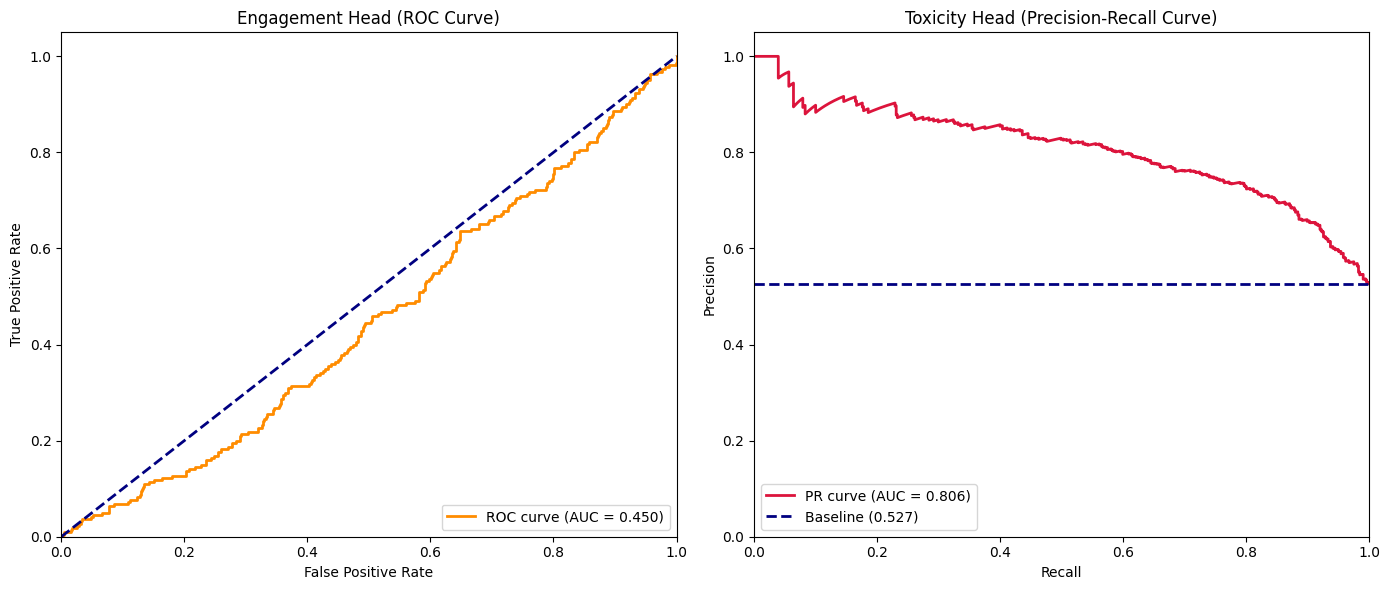

Train Loss: 1.2575, Valid Loss: 1.2210
Saved best model
Epoch 2/5
Batch 125: Loss = 1.2077
Batch 250: Loss = 1.1629
Batch 375: Loss = 1.1469
\n--- Validation Metrics ---
Engagement -> Accuracy: 0.7800 | ROC-AUC: 0.5000
Toxicity   -> Accuracy: 0.7240 | ROC-AUC: 0.7196 | PR-AUC: 0.6748\n


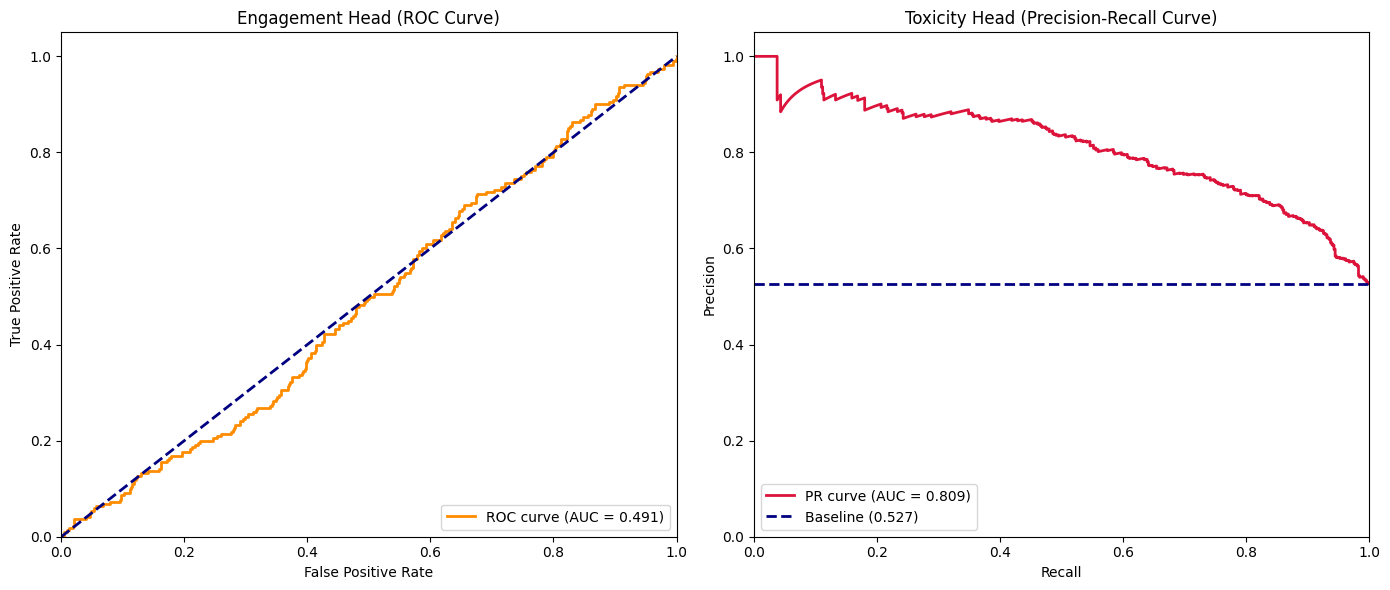

Train Loss: 1.1469, Valid Loss: 1.1401
Saved best model
Epoch 3/5
Batch 125: Loss = 1.1333
Batch 250: Loss = 1.0989
Batch 375: Loss = 1.0929
\n--- Validation Metrics ---
Engagement -> Accuracy: 0.7800 | ROC-AUC: 0.5000
Toxicity   -> Accuracy: 0.7380 | ROC-AUC: 0.7360 | PR-AUC: 0.6925\n


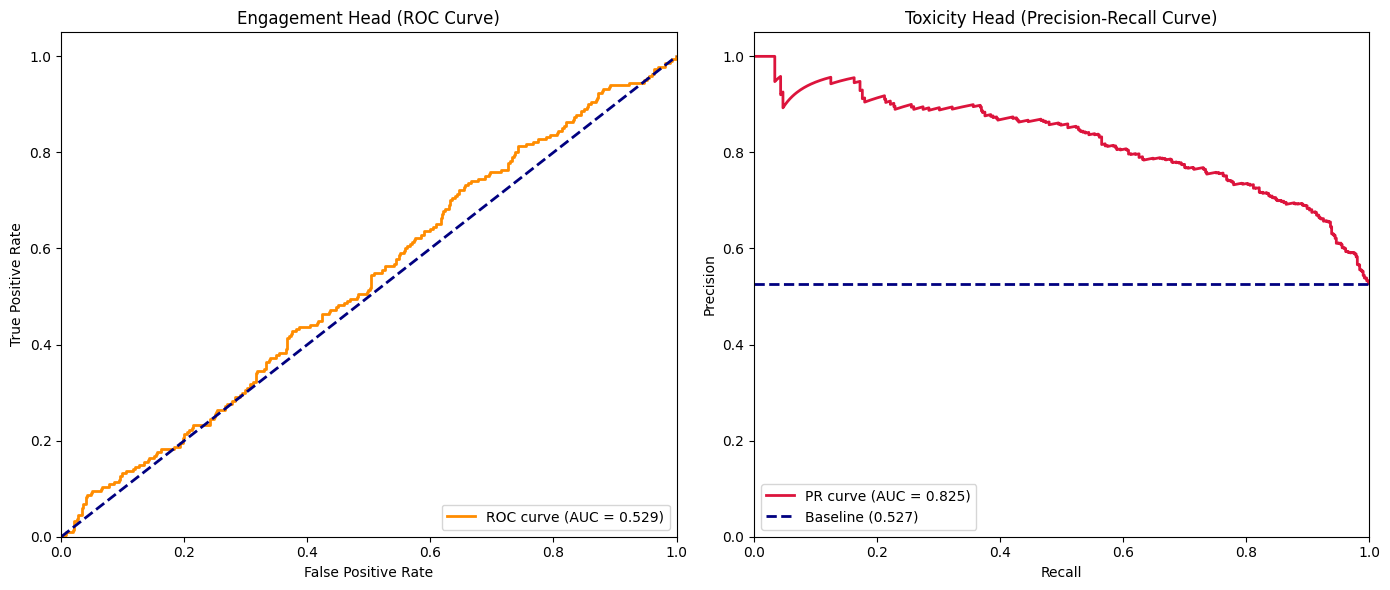

Train Loss: 1.0929, Valid Loss: 1.0908
Saved best model
Epoch 4/5
Batch 125: Loss = 1.0875
Batch 250: Loss = 1.0559
Batch 375: Loss = 1.0558
\n--- Validation Metrics ---
Engagement -> Accuracy: 0.7800 | ROC-AUC: 0.5000
Toxicity   -> Accuracy: 0.7490 | ROC-AUC: 0.7472 | PR-AUC: 0.7031\n


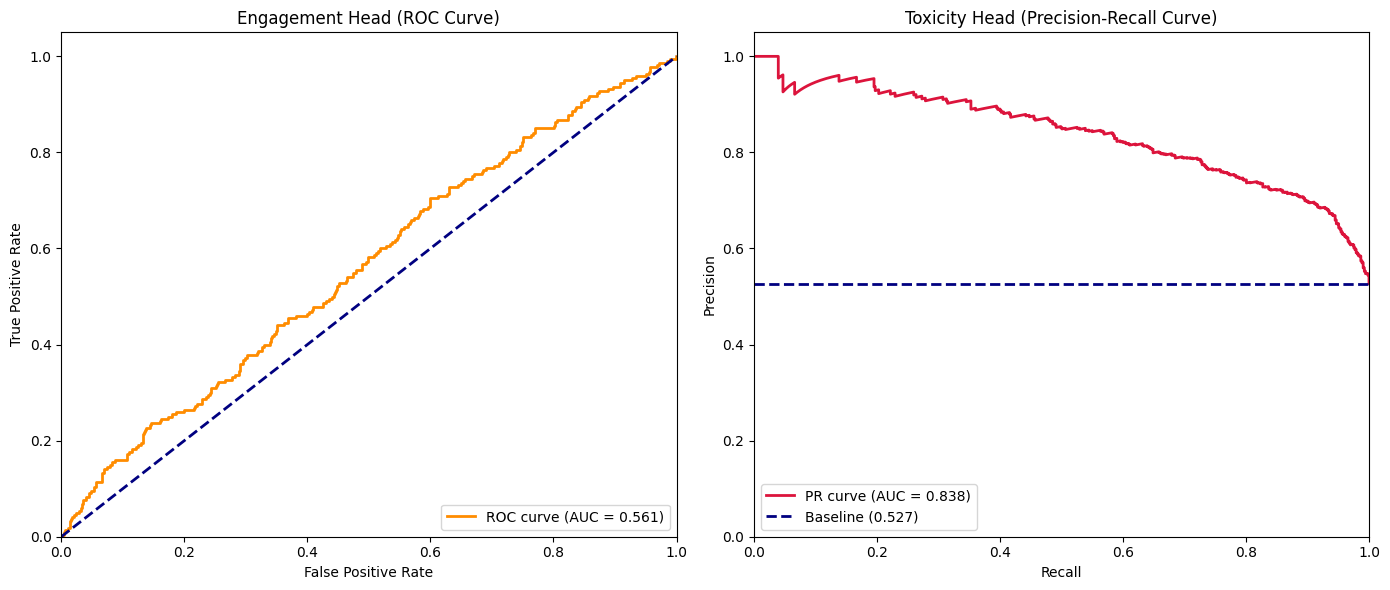

Train Loss: 1.0558, Valid Loss: 1.0550
Saved best model
Epoch 5/5
Batch 125: Loss = 1.0548
Batch 250: Loss = 1.0247
Batch 375: Loss = 1.0291
\n--- Validation Metrics ---
Engagement -> Accuracy: 0.7800 | ROC-AUC: 0.5000
Toxicity   -> Accuracy: 0.7510 | ROC-AUC: 0.7499 | PR-AUC: 0.7067\n


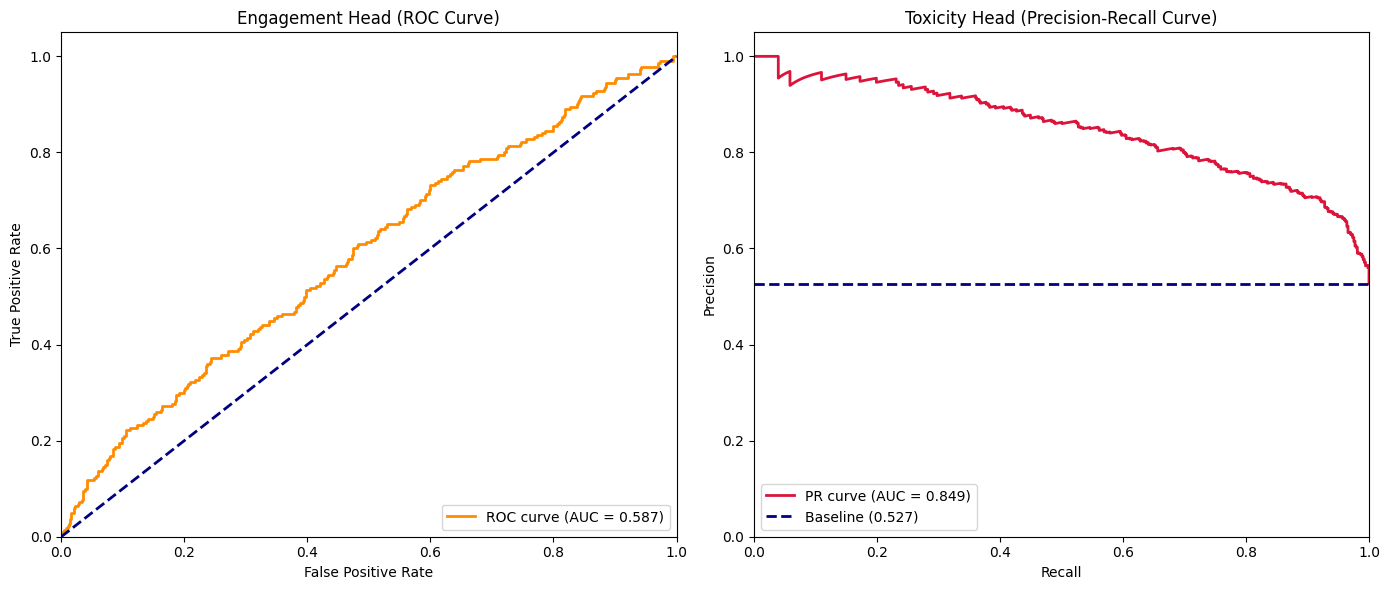

Train Loss: 1.0291, Valid Loss: 1.0287
Saved best model


In [62]:
train(shared_bottom_model, toxicity_train_dataloader, toxicity_valid_dataloader, criterion, optimizer)

### Testing

In [28]:
def inference(texts, model, encoder_model, device='cuda'):
    model.eval()
    print(f"--- QUALITATIVE INFERENCE TEST ---")
    print(f"{'INPUT TEXT':<60} | {'ENGAGEMENT PROB'} | {'TOXICITY PROB'}")
    print("-" * 95)

    
    with torch.no_grad():
        for text in texts:
            text_embeddings = encoder_model.encode(text)
            input_tensor = torch.tensor(text_embeddings, dtype=torch.float32).unsqueeze(0).to(device)
    
            eng_out, tox_out = model(input_tensor)
            eng_prob = eng_out.item()
            tox_prob = tox_out.item()
            
            # 4. Truncate text for clean formatting
            text_trunc = (text[:55] + '...') if len(text) > 55 else text
            
            # Print the side-by-side results
            print(f"{text_trunc:<60} | {eng_prob:.4f}          | {tox_prob:.4f}")

In [63]:
test_sentences = [
    "This is a very standard, polite news article about the economy.",
    "You are an absolute idiot, delete your account immediately.",
    "SHOCKING: 10 ways this celebrity ruined their life! (Must Read)",
    "I genuinely loved this movie, the cinematography was beautiful.",
    "This is a very normal line",
    "You bitch, I will kill you"
]

inference(test_sentences, shared_bottom_model, embedding_model)

--- QUALITATIVE INFERENCE TEST ---
INPUT TEXT                                                   | ENGAGEMENT PROB | TOXICITY PROB
-----------------------------------------------------------------------------------------------
This is a very standard, polite news article about the ...   | 0.1599          | 0.2525
You are an absolute idiot, delete your account immediat...   | 0.1611          | 0.8887
SHOCKING: 10 ways this celebrity ruined their life! (Mu...   | 0.1685          | 0.7015
I genuinely loved this movie, the cinematography was be...   | 0.3119          | 0.2080
This is a very normal line                                   | 0.1715          | 0.3406
You bitch, I will kill you                                   | 0.1966          | 0.7302


### Mixture Of Experts (MoE)

In [30]:
class GatingNetwork(nn.Module):
    def __init__(self, input_dim, num_experts):
        super().__init__()
        self.gate = nn.Linear(input_dim, num_experts)
        self.Softmax = nn.Softmax(dim=1)

    def forward(self, x):
        return self.Softmax(self.gate(x))

In [31]:
class ExpertNetwork(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, output_dim)
        self.ReLU = nn.ReLU()

    def forward(self, x):
        return self.ReLU(self.linear(x))

In [32]:
class BasicMoE(nn.Module):
    def __init__(self, input_dim, output_dim, num_experts, trained_experts=None):
        super().__init__()
        
        self.num_experts = num_experts
        
        if trained_experts: 
            for expert in trained_experts:
                for param in expert.parameters():
                    param.requires_grad = False

            self.experts = nn.ModuleList(expert.model_expert for expert in trained_experts)
            
        else:
            self.experts = nn.ModuleList(
                [
                    ExpertNetwork(input_dim, output_dim) for _ in range(self.num_experts)
                ]
            )

        self.gating_network = GatingNetwork(input_dim, self.num_experts)

        # 2. Task Head A: Engagement (Input 128 -> Output 1)
        self.engagement_head = trained_experts[0].model_head if trained_experts else nn.Sequential(
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

        # 2. Task Head B: Toxicity (Input 128 -> Output 1)
        self.toxicity_head = trained_experts[1].model_head if trained_experts else nn.Sequential(
            nn.Linear(128, 1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        expert_weight = self.gating_network(x)
        expert_out_list = [
            expert(x) for expert in self.experts
        ]
        expert_out = torch.stack(expert_out_list, dim=1)
        model_out = torch.sum(expert_weight @ expert_out, dim=1)

        engagement_out = self.engagement_head(model_out)
        toxicity_out = self.toxicity_head(model_out)
        return engagement_out, toxicity_out

In [64]:
basic_MoE_model = BasicMoE(384, 128, 8)
basic_MoE_model.to(device)
criterion = [nn.BCELoss(), nn.BCELoss()]
lr = 0.001
optimizer = torch.optim.Adam(basic_MoE_model.parameters(), lr=lr, weight_decay=0.001)

Epoch 1/5
Batch 125: Loss = 1.0644
Batch 250: Loss = 0.9721
Batch 375: Loss = 0.9814
\n--- Validation Metrics ---
Engagement -> Accuracy: 0.7880 | ROC-AUC: 0.5198
Toxicity   -> Accuracy: 0.7690 | ROC-AUC: 0.7685 | PR-AUC: 0.7257\n


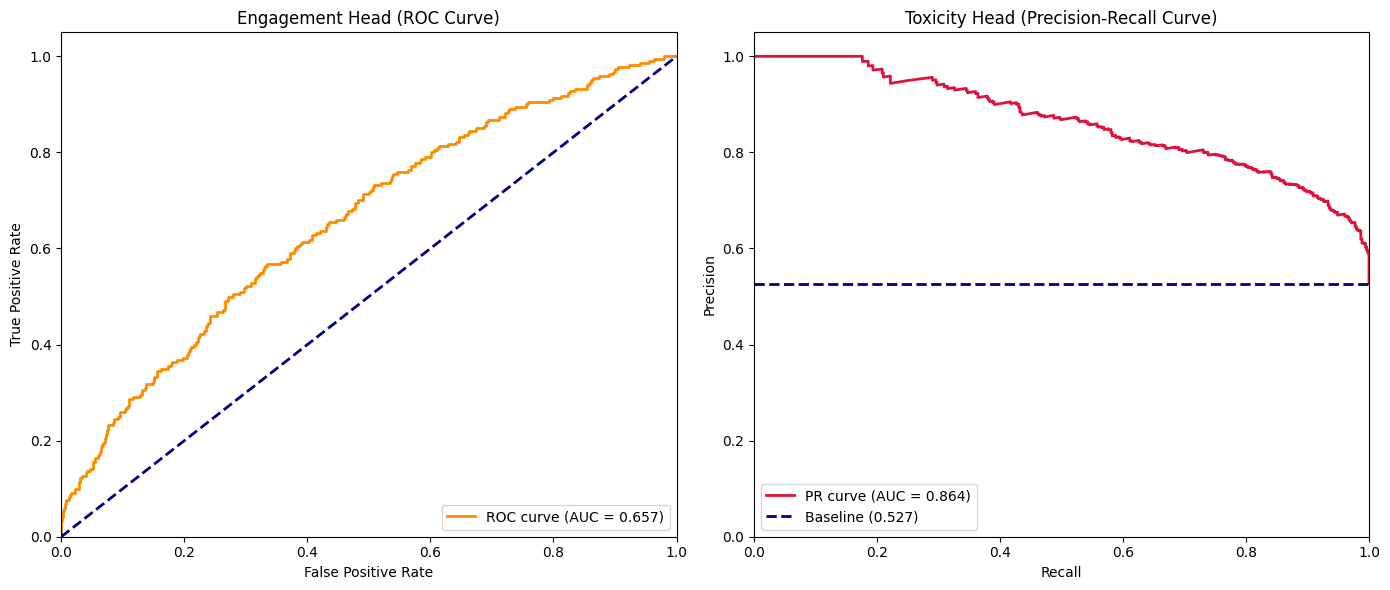

Train Loss: 0.9814, Valid Loss: 0.9694
Saved best model
Epoch 2/5
Batch 125: Loss = 0.9651
Batch 250: Loss = 0.9276
Batch 375: Loss = 0.9446
\n--- Validation Metrics ---
Engagement -> Accuracy: 0.7890 | ROC-AUC: 0.5270
Toxicity   -> Accuracy: 0.7710 | ROC-AUC: 0.7710 | PR-AUC: 0.7295\n


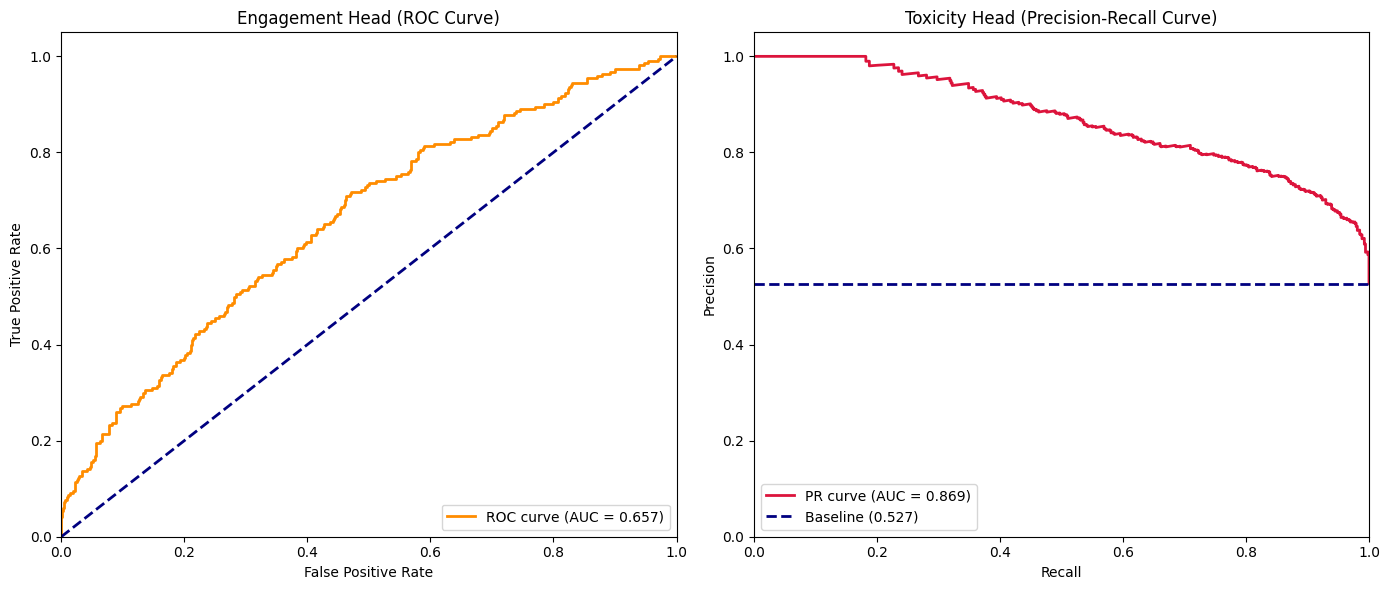

Train Loss: 0.9446, Valid Loss: 0.9641
Saved best model
Epoch 3/5
Batch 125: Loss = 0.9440
Batch 250: Loss = 0.9071
Batch 375: Loss = 0.9206
\n--- Validation Metrics ---
Engagement -> Accuracy: 0.7930 | ROC-AUC: 0.5361
Toxicity   -> Accuracy: 0.7670 | ROC-AUC: 0.7672 | PR-AUC: 0.7263\n


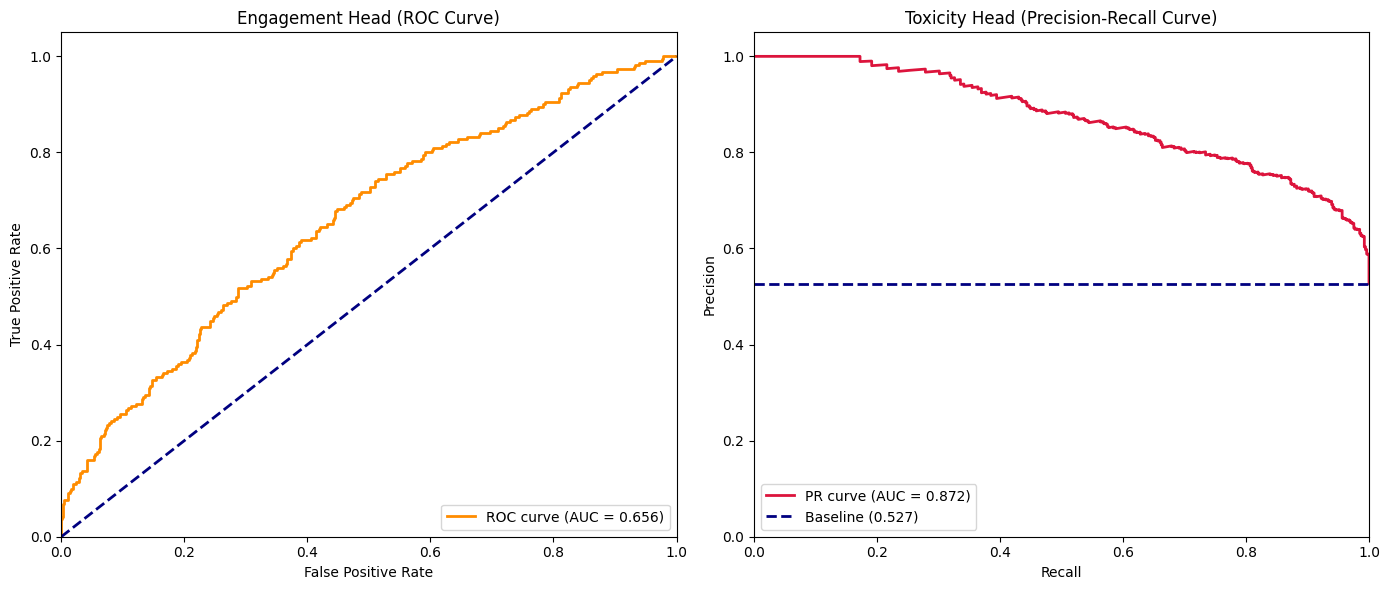

Train Loss: 0.9206, Valid Loss: 0.9622
Saved best model
Epoch 4/5
Batch 125: Loss = 0.9257
Batch 250: Loss = 0.8874
Batch 375: Loss = 0.8966
\n--- Validation Metrics ---
Engagement -> Accuracy: 0.7940 | ROC-AUC: 0.5400
Toxicity   -> Accuracy: 0.7600 | ROC-AUC: 0.7611 | PR-AUC: 0.7224\n


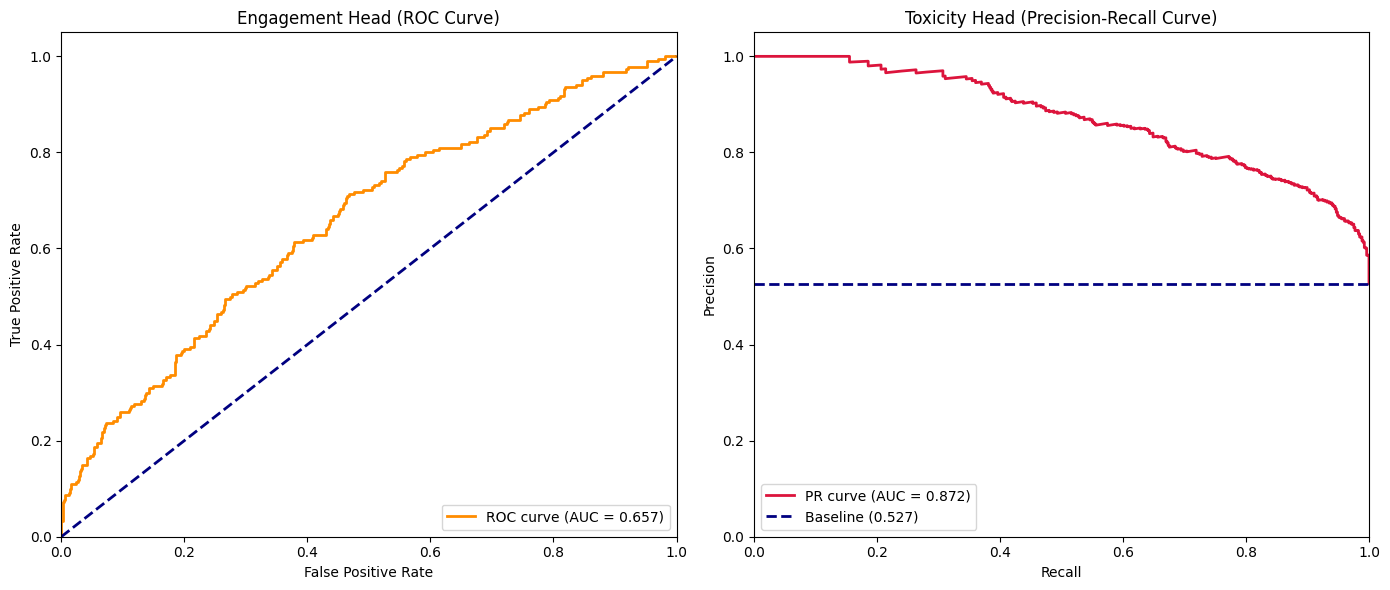

Train Loss: 0.8966, Valid Loss: 0.9633
Epoch 5/5
Batch 125: Loss = 0.9040
Batch 250: Loss = 0.8646
Batch 375: Loss = 0.8704
\n--- Validation Metrics ---
Engagement -> Accuracy: 0.7900 | ROC-AUC: 0.5358
Toxicity   -> Accuracy: 0.7560 | ROC-AUC: 0.7579 | PR-AUC: 0.7210\n


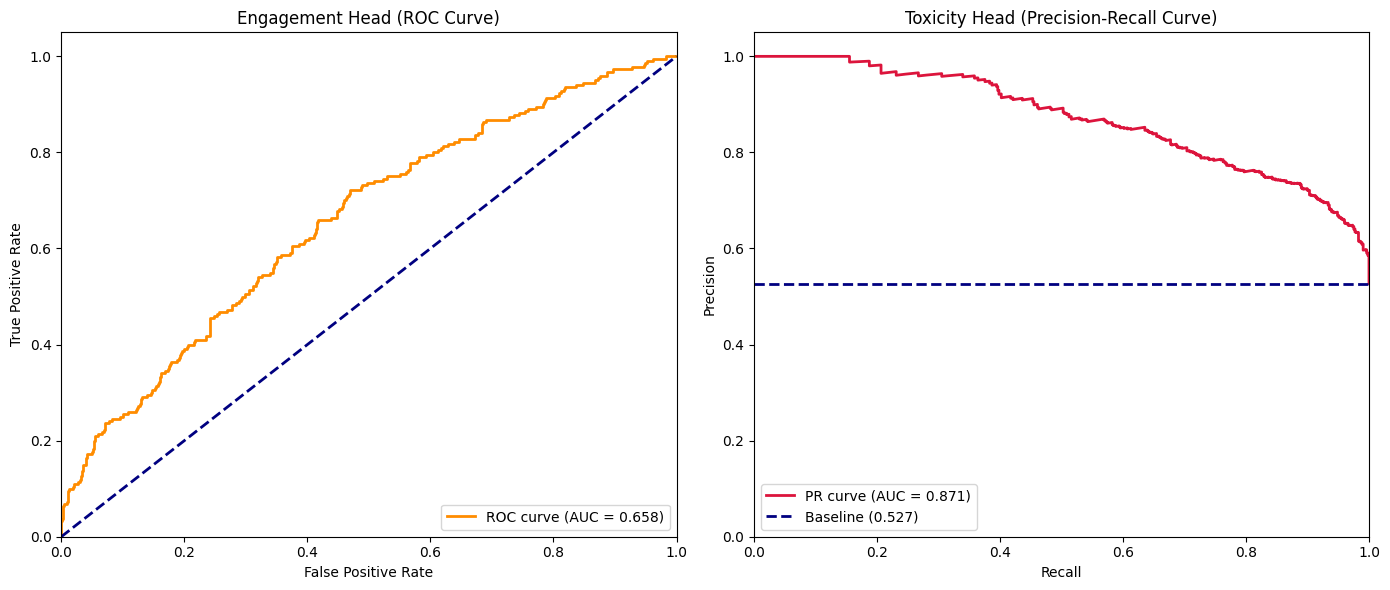

Train Loss: 0.8704, Valid Loss: 0.9696


In [65]:
train(basic_MoE_model, toxicity_train_dataloader, toxicity_valid_dataloader, criterion, optimizer)

In [66]:
inference(test_sentences, basic_MoE_model, embedding_model)

--- QUALITATIVE INFERENCE TEST ---
INPUT TEXT                                                   | ENGAGEMENT PROB | TOXICITY PROB
-----------------------------------------------------------------------------------------------
This is a very standard, polite news article about the ...   | 0.4769          | 0.4756
You are an absolute idiot, delete your account immediat...   | 0.4709          | 0.5407
SHOCKING: 10 ways this celebrity ruined their life! (Mu...   | 0.4833          | 0.5001
I genuinely loved this movie, the cinematography was be...   | 0.4828          | 0.4601
This is a very normal line                                   | 0.4737          | 0.4800
You bitch, I will kill you                                   | 0.4722          | 0.5079


## MMoE

In [36]:
class BasicMMoE(nn.Module):
    def __init__(self, input_dim, output_dim, num_experts):
        super().__init__()
        
        self.num_experts = num_experts
        self.experts = nn.ModuleList(
            [
                ExpertNetwork(input_dim, output_dim) for _ in range(self.num_experts)
            ]
        )

        self.engagement_gate = GatingNetwork(input_dim, self.num_experts)
        self.toxicity_gate = GatingNetwork(input_dim, self.num_experts)

        # 2. Task Head A: Engagement (Input 128 -> Output 1)
        self.engagement_head = nn.Sequential(
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

        # 2. Task Head B: Toxicity (Input 128 -> Output 1)
        self.toxicity_head = nn.Sequential(
            nn.Linear(128, 1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        expert_weight_engagement = self.engagement_gate(x)
        expert_weight_toxicity = self.toxicity_gate(x)
        
        expert_out_list = [
            expert(x) for expert in self.experts
        ]
        expert_out = torch.stack(expert_out_list, dim=1)
        expert_engagement_out = torch.sum(expert_weight_engagement @ expert_out, dim=1)
        expert_toxicity_out = torch.sum(expert_weight_toxicity @ expert_out, dim=1)

        engagement_out = self.engagement_head(expert_engagement_out)
        toxicity_out = self.toxicity_head(expert_toxicity_out)
        return engagement_out, toxicity_out

In [37]:
basic_MMoE_model = BasicMMoE(384, 128, 8)
basic_MMoE_model.to(device)
criterion = [nn.BCELoss(), nn.BCELoss()]
lr = 0.001
optimizer = torch.optim.Adam(basic_MMoE_model.parameters(), lr=lr, weight_decay=0.001)

Epoch 1/5
Batch 125: Loss = 1.1654
Batch 250: Loss = 1.0991
Batch 375: Loss = 1.1000
\n--- Validation Metrics ---
Engagement -> Accuracy: 0.6880 | ROC-AUC: 0.5020
Toxicity   -> Accuracy: 0.7685 | ROC-AUC: 0.7685 | PR-AUC: 0.7001\n


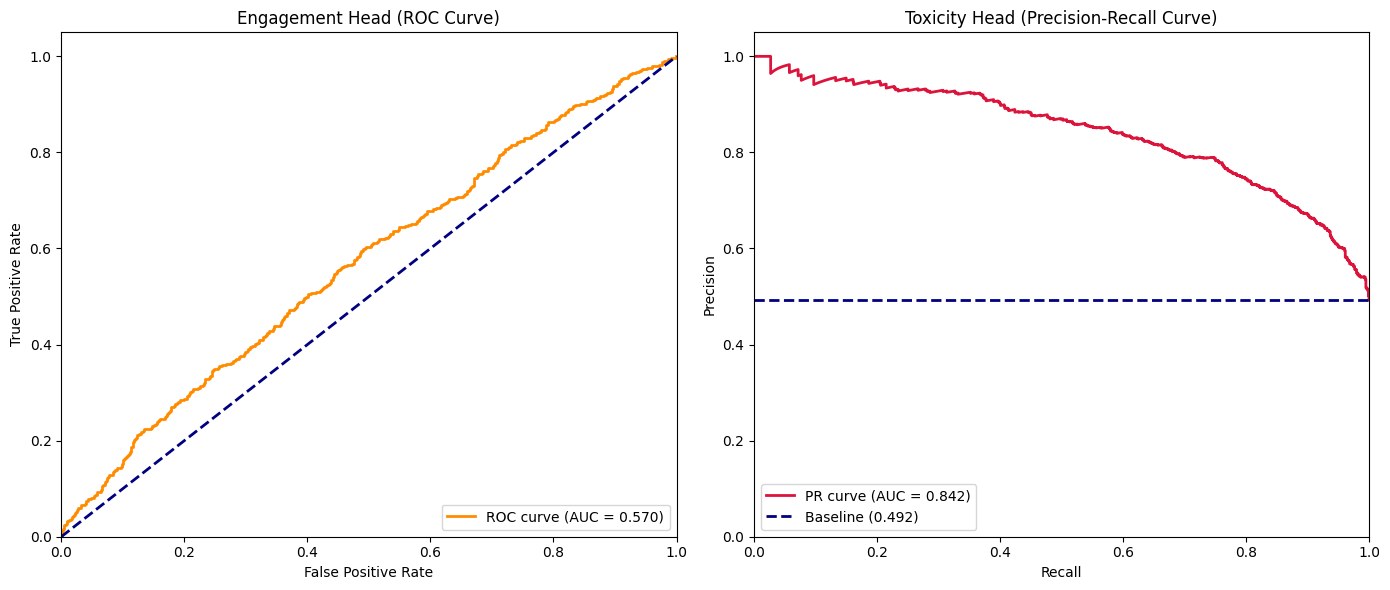

Train Loss: 1.1000, Valid Loss: 1.1021
Saved best model
Epoch 2/5
Batch 125: Loss = 1.0798
Batch 250: Loss = 1.0639
Batch 375: Loss = 1.0680
\n--- Validation Metrics ---
Engagement -> Accuracy: 0.6890 | ROC-AUC: 0.5041
Toxicity   -> Accuracy: 0.7755 | ROC-AUC: 0.7755 | PR-AUC: 0.7077\n


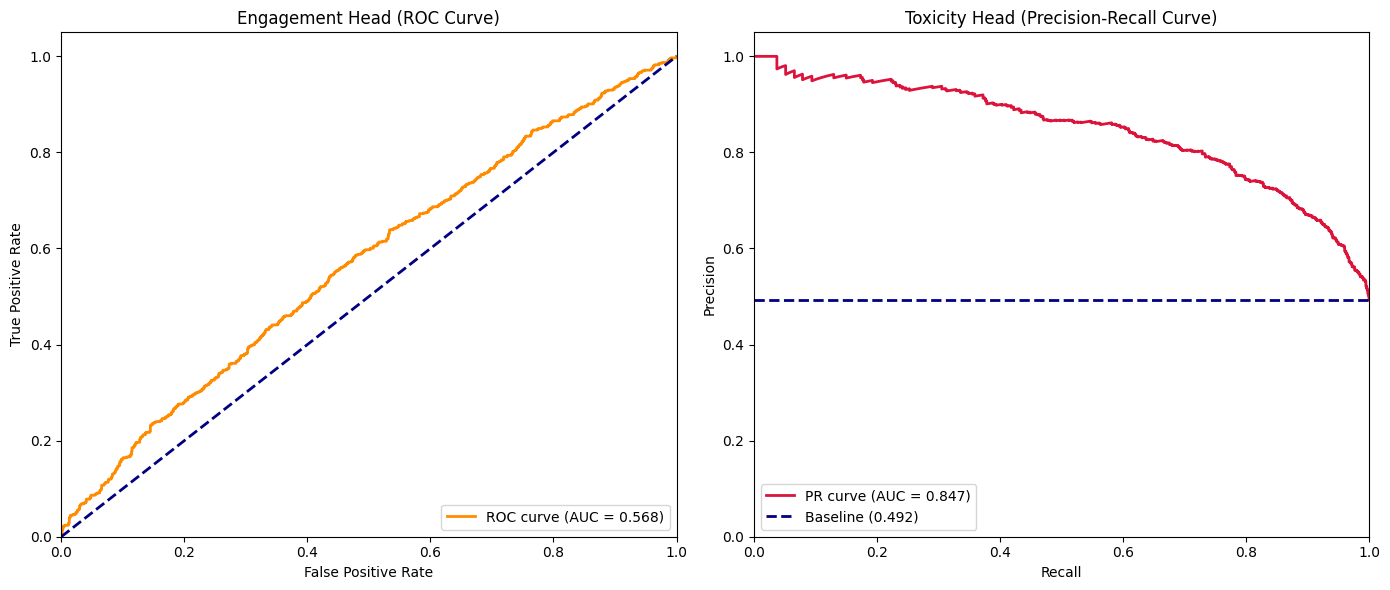

Train Loss: 1.0680, Valid Loss: 1.0980
Saved best model
Epoch 3/5
Batch 125: Loss = 1.0624
Batch 250: Loss = 1.0482
Batch 375: Loss = 1.0494
\n--- Validation Metrics ---
Engagement -> Accuracy: 0.6900 | ROC-AUC: 0.5070
Toxicity   -> Accuracy: 0.7745 | ROC-AUC: 0.7745 | PR-AUC: 0.7064\n


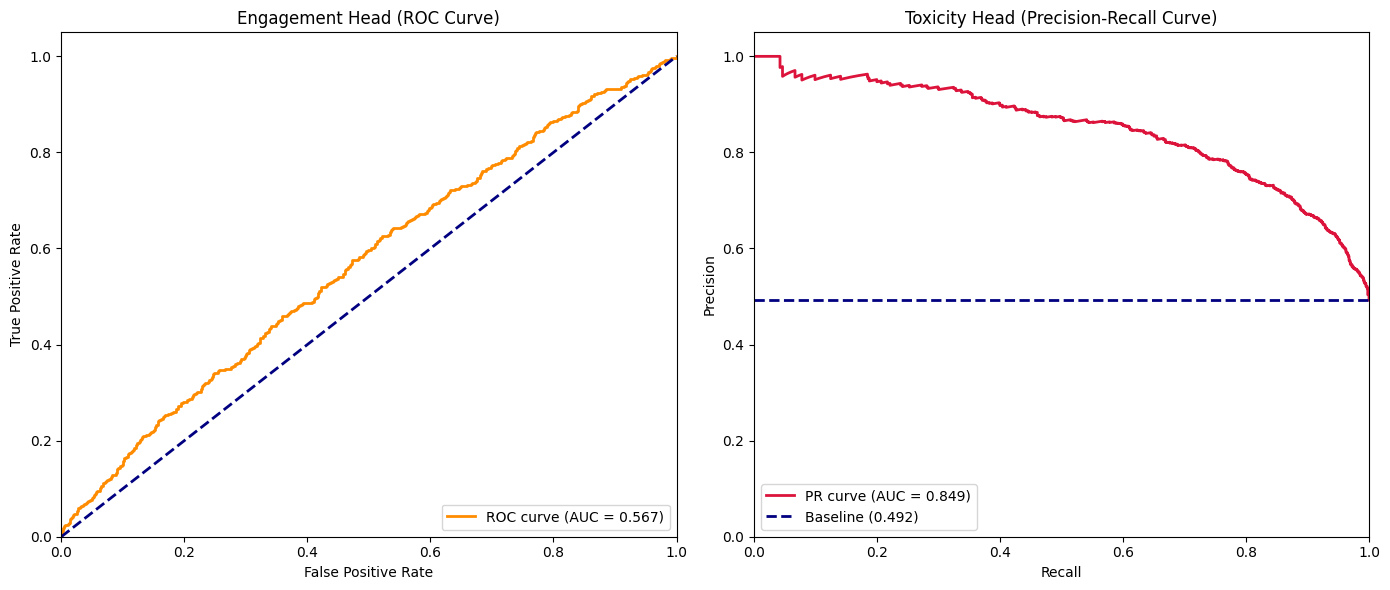

Train Loss: 1.0494, Valid Loss: 1.0966
Saved best model
Epoch 4/5
Batch 125: Loss = 1.0459
Batch 250: Loss = 1.0328
Batch 375: Loss = 1.0311
\n--- Validation Metrics ---
Engagement -> Accuracy: 0.6910 | ROC-AUC: 0.5125
Toxicity   -> Accuracy: 0.7775 | ROC-AUC: 0.7774 | PR-AUC: 0.7109\n


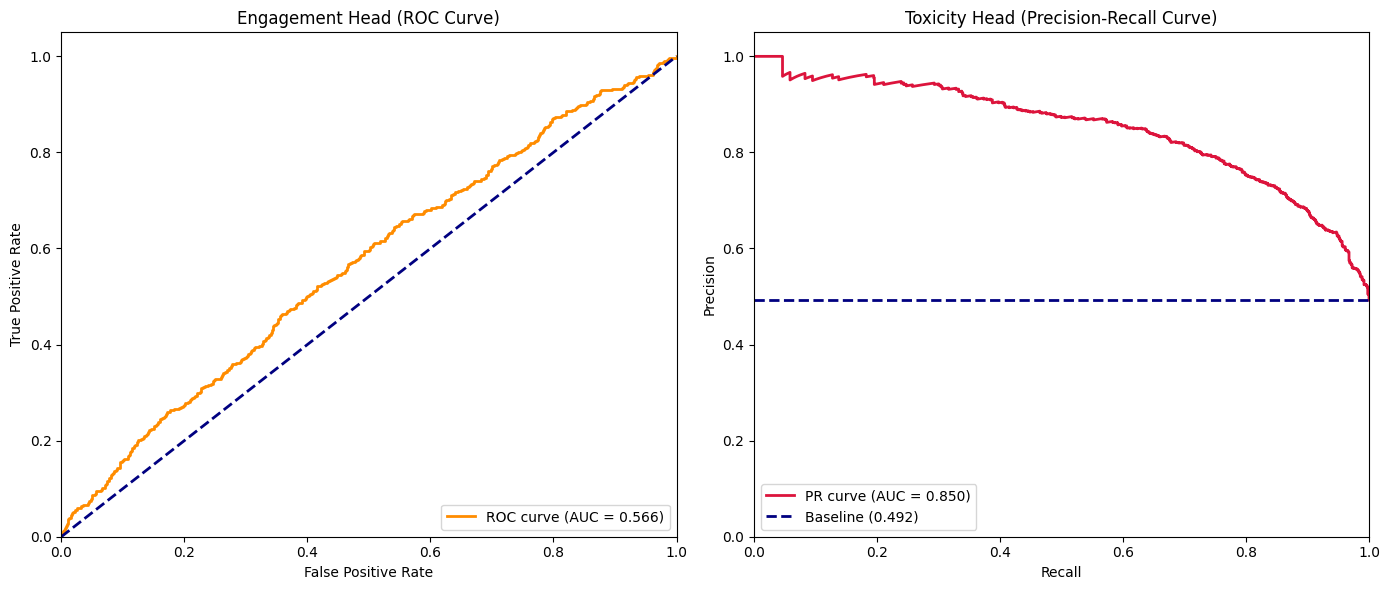

Train Loss: 1.0311, Valid Loss: 1.0968
Epoch 5/5
Batch 125: Loss = 1.0292
Batch 250: Loss = 1.0145
Batch 375: Loss = 1.0092
\n--- Validation Metrics ---
Engagement -> Accuracy: 0.6890 | ROC-AUC: 0.5136
Toxicity   -> Accuracy: 0.7785 | ROC-AUC: 0.7783 | PR-AUC: 0.7134\n


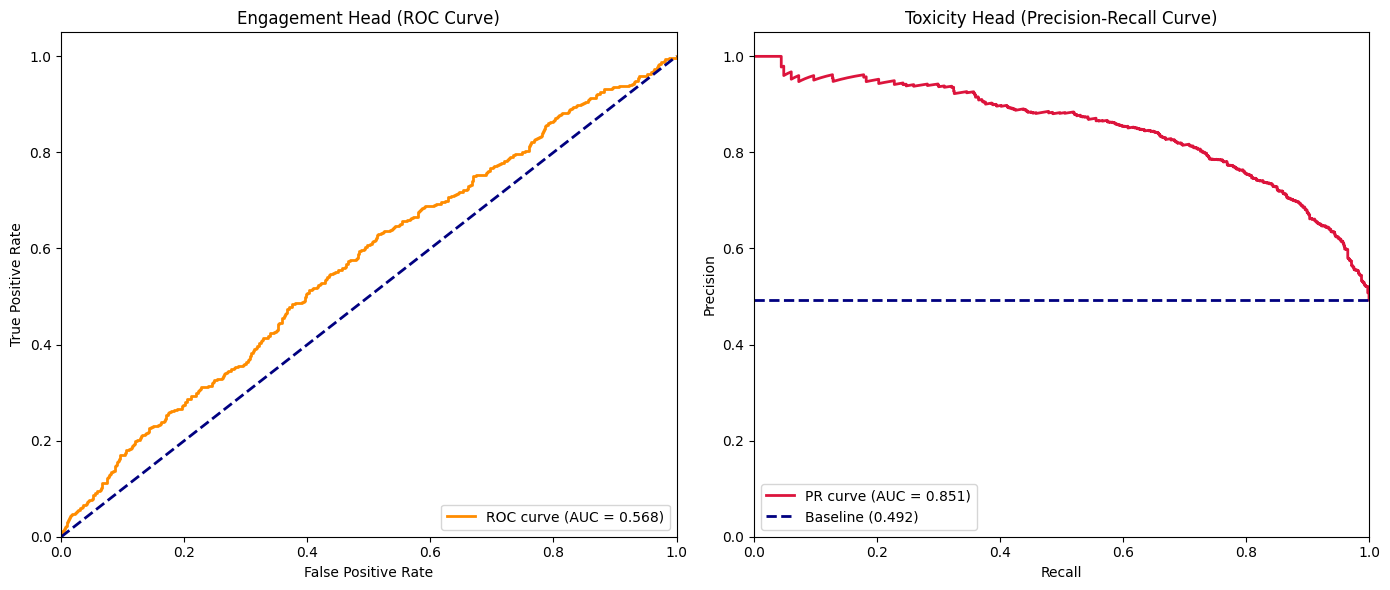

Train Loss: 1.0092, Valid Loss: 1.0984


In [38]:
train(basic_MMoE_model, toxicity_train_dataloader, toxicity_valid_dataloader, criterion, optimizer)

In [39]:
inference(test_sentences, basic_MMoE_model, embedding_model)

--- QUALITATIVE INFERENCE TEST ---
INPUT TEXT                                                   | ENGAGEMENT PROB | TOXICITY PROB
-----------------------------------------------------------------------------------------------
This is a very standard, polite news article about the ...   | 0.4948          | 0.4898
You are an absolute idiot, delete your account immediat...   | 0.4930          | 0.5500
SHOCKING: 10 ways this celebrity ruined their life! (Mu...   | 0.4959          | 0.5164
I genuinely loved this movie, the cinematography was be...   | 0.4899          | 0.4650
This is a very normal line                                   | 0.4889          | 0.4754
You bitch, I will kill you                                   | 0.4922          | 0.5106


## Basic MoE with Trained Experts

In [67]:
engagement_expert = nn.Sequential(OrderedDict([
    ('model_expert', nn.Sequential(
        nn.Linear(384, 128),
        nn.ReLU()
    )),
    ('model_head', nn.Sequential(
        nn.Linear(128, 1),
        nn.Sigmoid()
    ))
]))
engagement_expert.to(device)
criterion = nn.BCELoss()
lr = 0.001
optimizer = torch.optim.Adam(engagement_expert.parameters(), lr=lr, weight_decay=0.001)

Epoch 1/5
Batch 125: Loss = 0.5608
Batch 250: Loss = 0.4997
Batch 375: Loss = 0.4882
\n--- Validation Metrics ---
engagement   -> Accuracy: 0.7800 | ROC-AUC: 0.5000 | PR-AUC: 0.2200\n


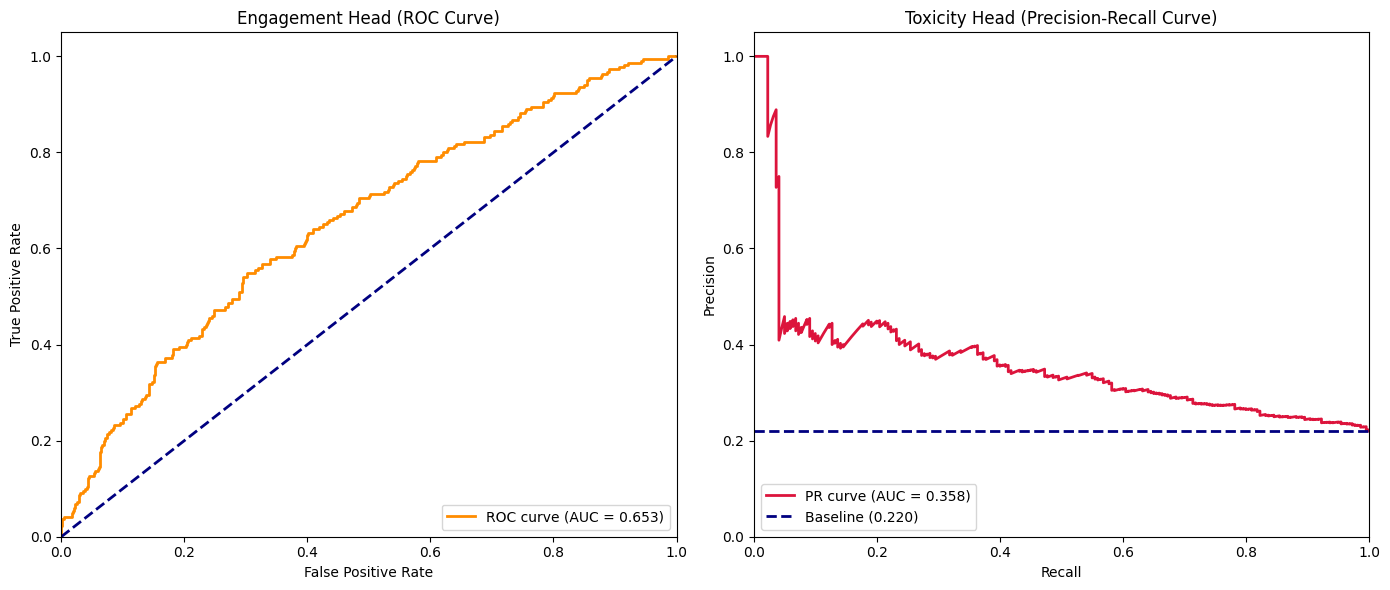

Train Loss: 0.4882, Valid Loss: 0.5007
Saved best model
Epoch 2/5
Batch 125: Loss = 0.4960
Batch 250: Loss = 0.4849
Batch 375: Loss = 0.4774
\n--- Validation Metrics ---
engagement   -> Accuracy: 0.7800 | ROC-AUC: 0.5000 | PR-AUC: 0.2200\n


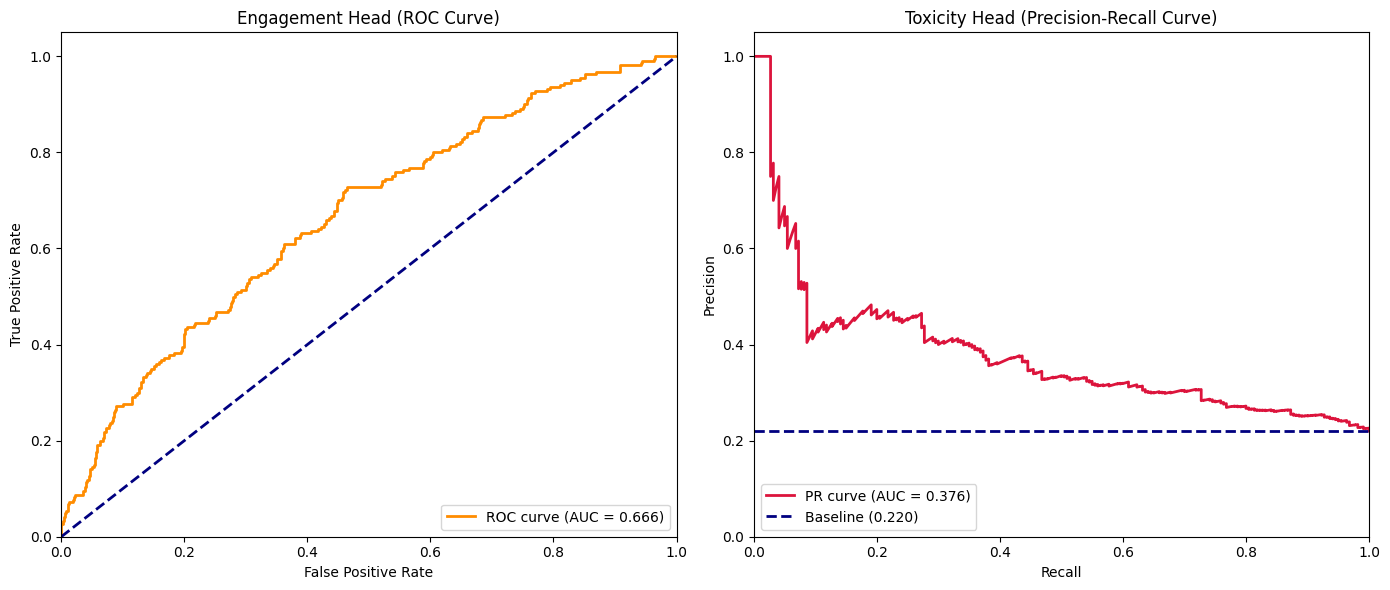

Train Loss: 0.4774, Valid Loss: 0.4945
Saved best model
Epoch 3/5
Batch 125: Loss = 0.4924
Batch 250: Loss = 0.4827
Batch 375: Loss = 0.4748
\n--- Validation Metrics ---
engagement   -> Accuracy: 0.7800 | ROC-AUC: 0.5000 | PR-AUC: 0.2200\n


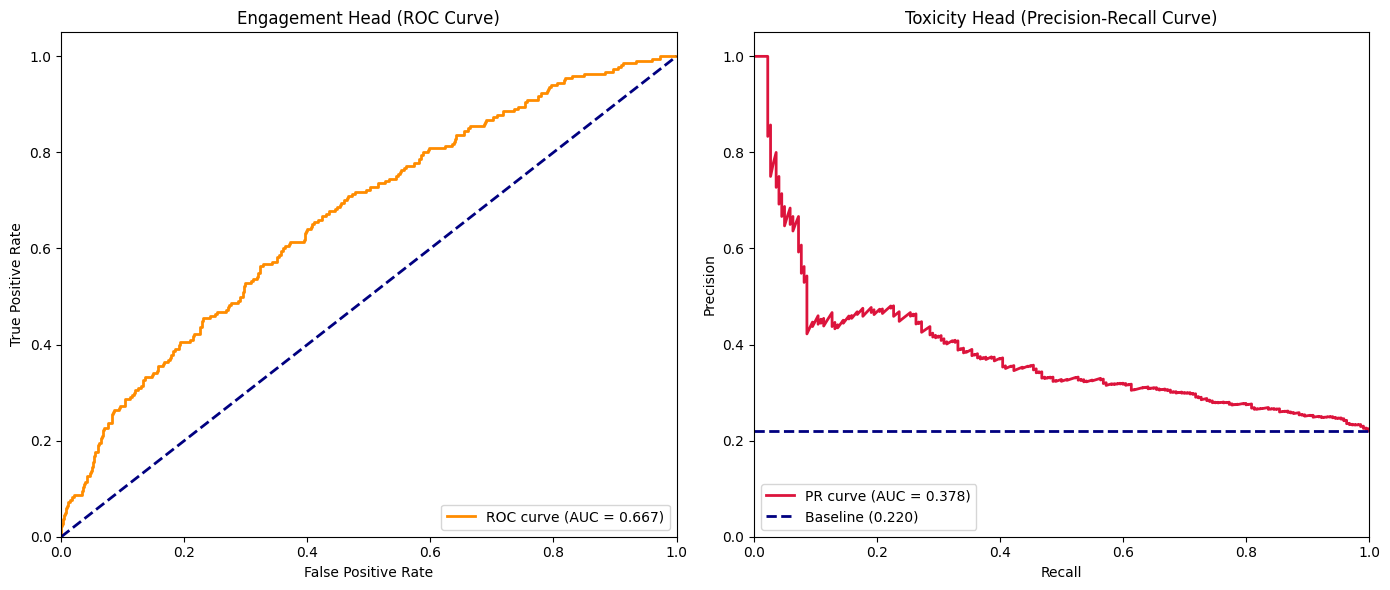

Train Loss: 0.4748, Valid Loss: 0.4934
Saved best model
Epoch 4/5
Batch 125: Loss = 0.4915
Batch 250: Loss = 0.4820
Batch 375: Loss = 0.4738
\n--- Validation Metrics ---
engagement   -> Accuracy: 0.7800 | ROC-AUC: 0.5000 | PR-AUC: 0.2200\n


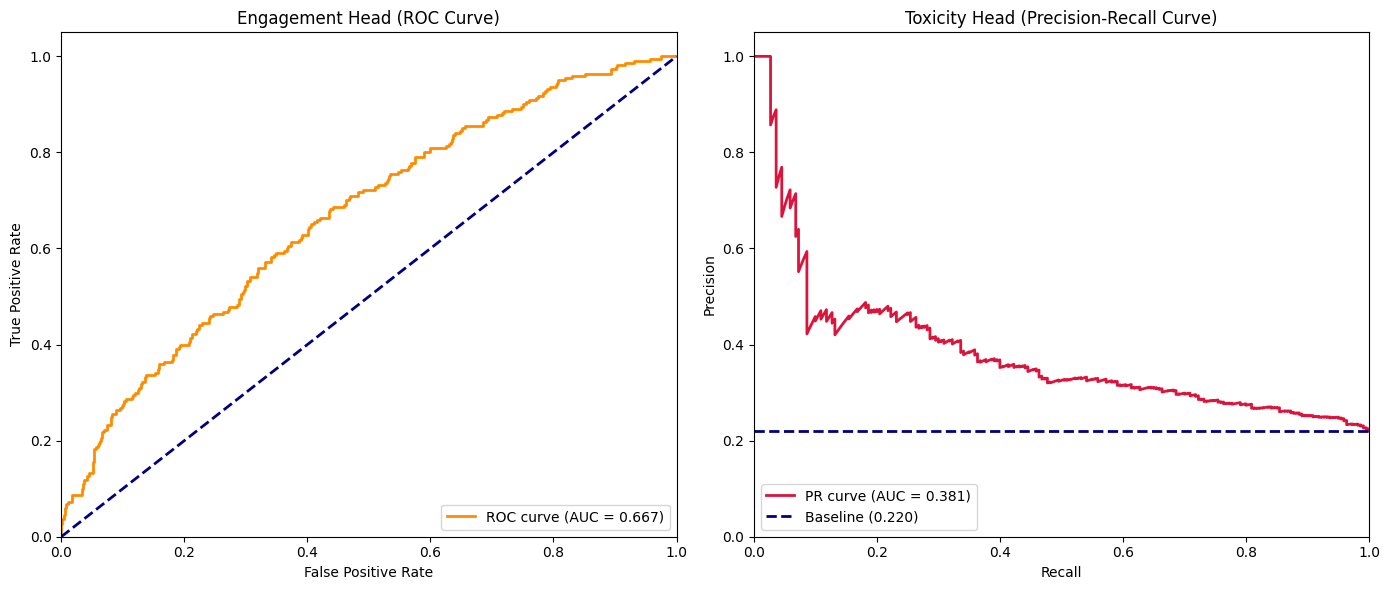

Train Loss: 0.4738, Valid Loss: 0.4931
Saved best model
Epoch 5/5
Batch 125: Loss = 0.4910
Batch 250: Loss = 0.4816
Batch 375: Loss = 0.4732
\n--- Validation Metrics ---
engagement   -> Accuracy: 0.7800 | ROC-AUC: 0.5000 | PR-AUC: 0.2200\n


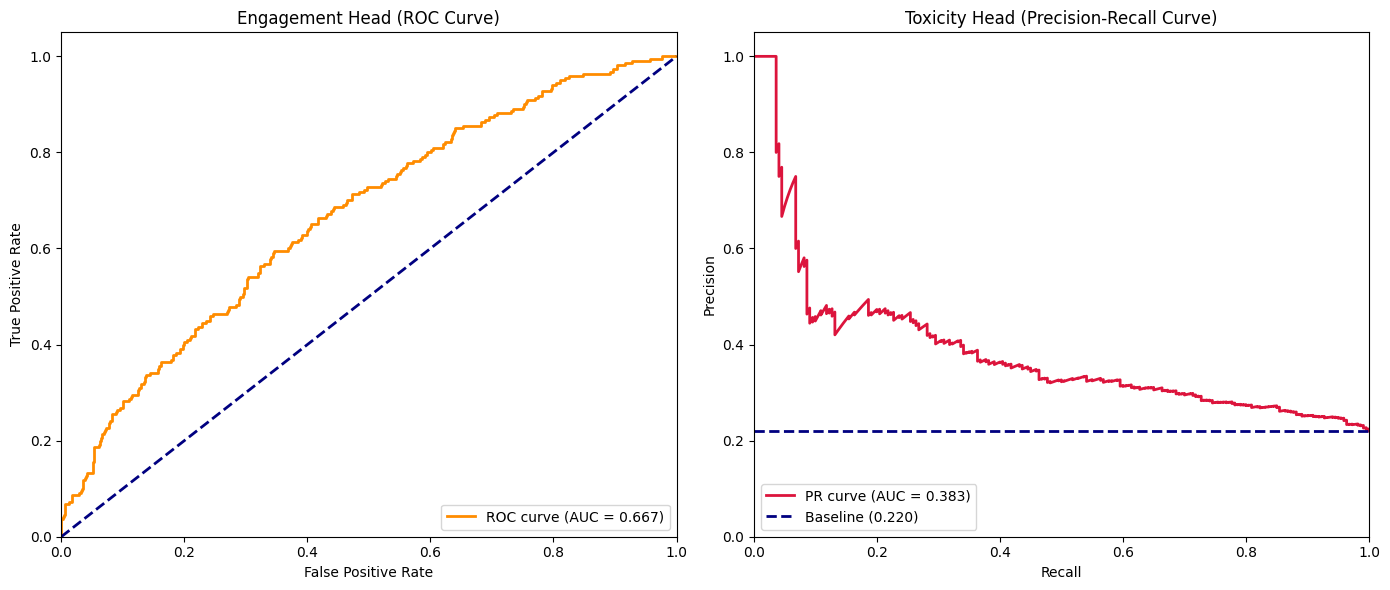

Train Loss: 0.4732, Valid Loss: 0.4930
Saved best model


In [68]:
train(engagement_expert, toxicity_train_dataloader, toxicity_valid_dataloader, criterion, optimizer, 5, "engagement")

In [69]:
def inference_expert(texts, model, encoder_model, device='cuda'):
    model.eval()
    print(f"--- QUALITATIVE INFERENCE TEST ---")
    print(f"{'INPUT TEXT':<60} | {'ENGAGEMENT PROB'} | {'TOXICITY PROB'}")
    print("-" * 95)

    
    with torch.no_grad():
        for text in texts:
            text_embeddings = encoder_model.encode(text)
            input_tensor = torch.tensor(text_embeddings, dtype=torch.float32).unsqueeze(0).to(device)
    
            exp = model(input_tensor)
            exp_prob = exp.item()
            
            # 4. Truncate text for clean formatting
            text_trunc = (text[:55] + '...') if len(text) > 55 else text
            
            # Print the side-by-side results
            print(f"{text_trunc:<60} | {exp_prob:.4f}")

In [70]:
inference_expert(test_sentences, engagement_expert, embedding_model)

--- QUALITATIVE INFERENCE TEST ---
INPUT TEXT                                                   | ENGAGEMENT PROB | TOXICITY PROB
-----------------------------------------------------------------------------------------------
This is a very standard, polite news article about the ...   | 0.1293
You are an absolute idiot, delete your account immediat...   | 0.1105
SHOCKING: 10 ways this celebrity ruined their life! (Mu...   | 0.2506
I genuinely loved this movie, the cinematography was be...   | 0.2055
This is a very normal line                                   | 0.1139
You bitch, I will kill you                                   | 0.1486


In [71]:
toxicity_expert = nn.Sequential(OrderedDict([
    ('model_expert', nn.Sequential(
        nn.Linear(384, 128),
        nn.ReLU()
    )),
    ('model_head', nn.Sequential(
        nn.Linear(128, 1),
        nn.Sigmoid()
    ))
]))

toxicity_expert.to(device)
criterion = nn.BCELoss()
lr = 0.001
optimizer = torch.optim.Adam(toxicity_expert.parameters(), lr=lr, weight_decay=0.0001)

Epoch 1/5
Batch 125: Loss = 0.6213
Batch 250: Loss = 0.5037
Batch 375: Loss = 0.5033
\n--- Validation Metrics ---
toxicity   -> Accuracy: 0.7710 | ROC-AUC: 0.7697 | PR-AUC: 0.7253\n


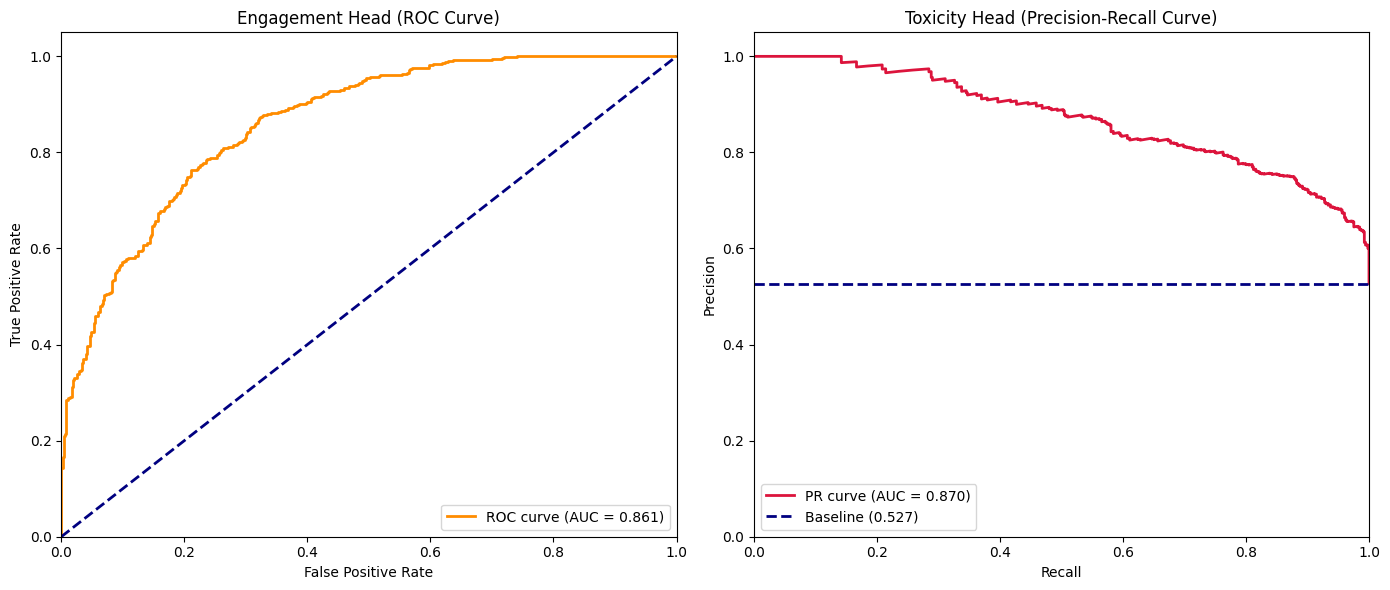

Train Loss: 0.5033, Valid Loss: 0.4616
Saved best model
Epoch 2/5
Batch 125: Loss = 0.4857
Batch 250: Loss = 0.4578
Batch 375: Loss = 0.4875
\n--- Validation Metrics ---
toxicity   -> Accuracy: 0.7760 | ROC-AUC: 0.7756 | PR-AUC: 0.7329\n


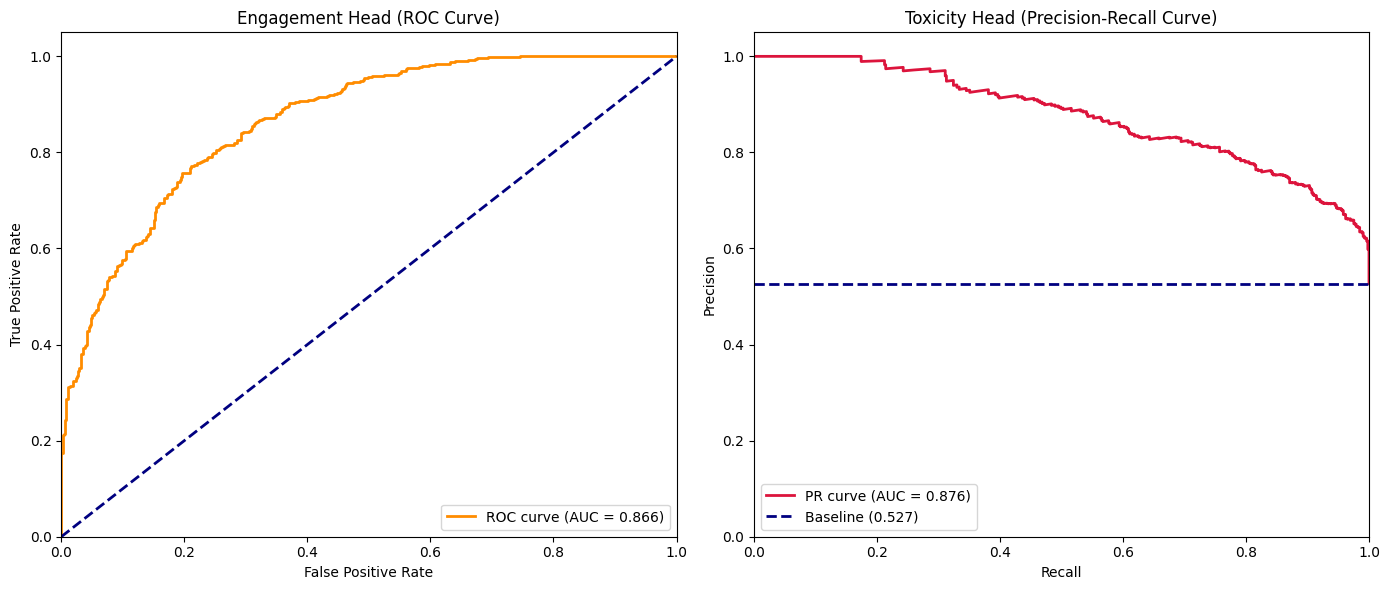

Train Loss: 0.4875, Valid Loss: 0.4521
Saved best model
Epoch 3/5
Batch 125: Loss = 0.4745
Batch 250: Loss = 0.4492
Batch 375: Loss = 0.4811
\n--- Validation Metrics ---
toxicity   -> Accuracy: 0.7760 | ROC-AUC: 0.7757 | PR-AUC: 0.7332\n


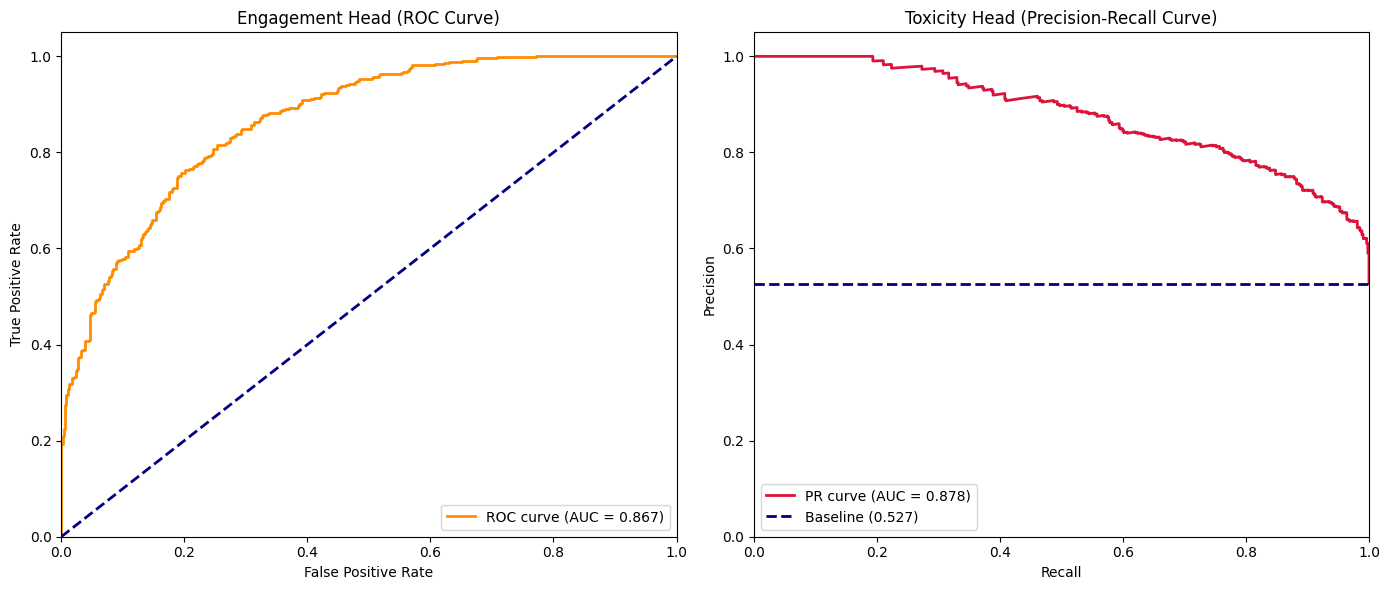

Train Loss: 0.4811, Valid Loss: 0.4488
Saved best model
Epoch 4/5
Batch 125: Loss = 0.4687
Batch 250: Loss = 0.4441
Batch 375: Loss = 0.4764
\n--- Validation Metrics ---
toxicity   -> Accuracy: 0.7750 | ROC-AUC: 0.7747 | PR-AUC: 0.7324\n


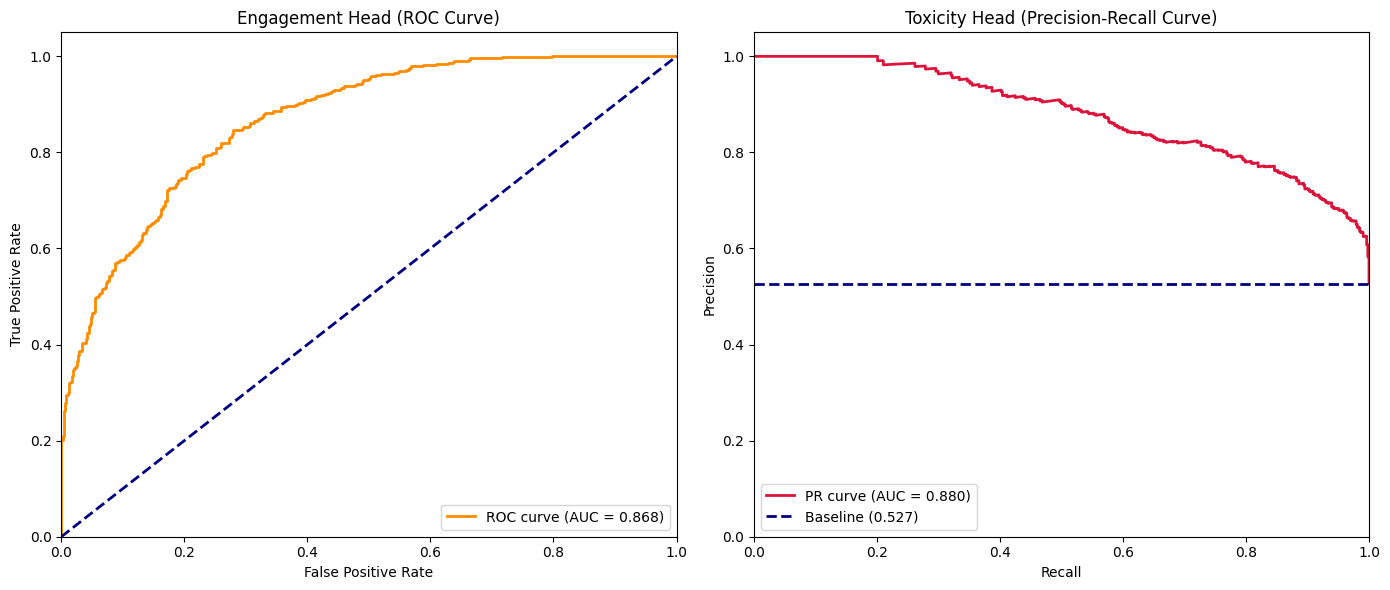

Train Loss: 0.4764, Valid Loss: 0.4470
Saved best model
Epoch 5/5
Batch 125: Loss = 0.4642
Batch 250: Loss = 0.4396
Batch 375: Loss = 0.4720
\n--- Validation Metrics ---
toxicity   -> Accuracy: 0.7770 | ROC-AUC: 0.7766 | PR-AUC: 0.7340\n


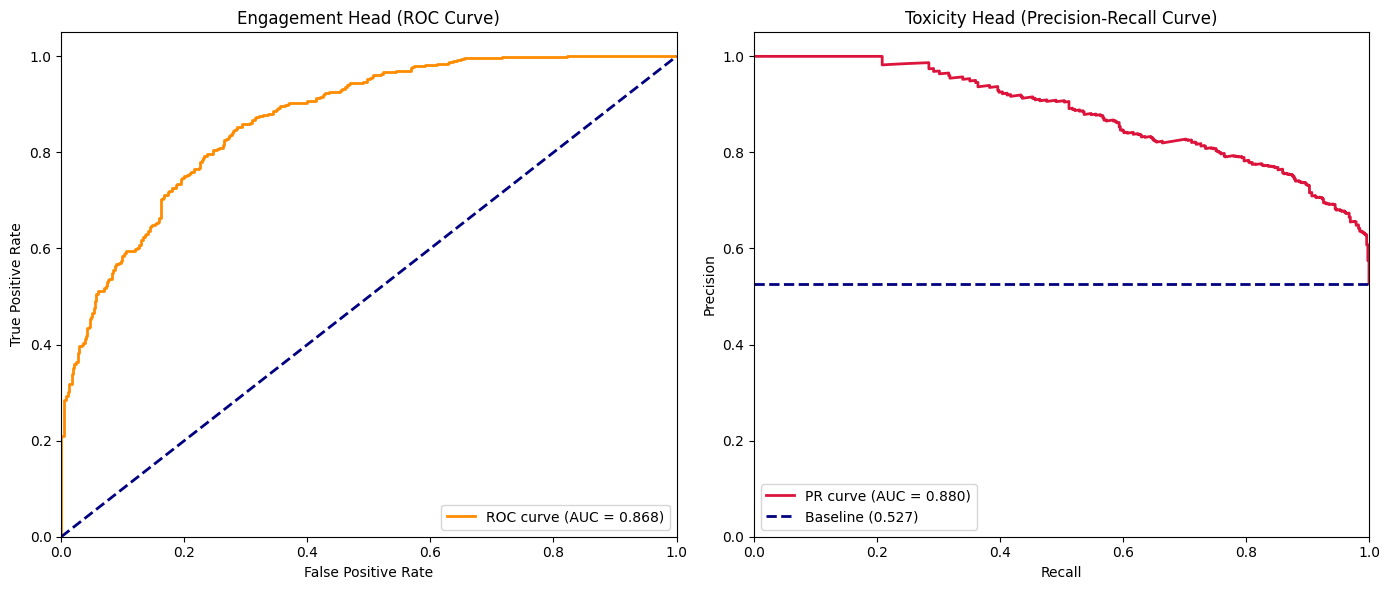

Train Loss: 0.4720, Valid Loss: 0.4459
Saved best model


In [72]:
train(toxicity_expert, toxicity_train_dataloader, toxicity_valid_dataloader, criterion, optimizer, 5, "toxicity")

In [77]:
inference_expert(test_sentences, toxicity_expert, embedding_model)

--- QUALITATIVE INFERENCE TEST ---
INPUT TEXT                                                   | ENGAGEMENT PROB | TOXICITY PROB
-----------------------------------------------------------------------------------------------
This is a very standard, polite news article about the ...   | 0.1050
You are an absolute idiot, delete your account immediat...   | 0.9880
SHOCKING: 10 ways this celebrity ruined their life! (Mu...   | 0.8071
I genuinely loved this movie, the cinematography was be...   | 0.0556
This is a very normal line                                   | 0.1422
You bitch, I will kill you                                   | 0.8577


In [74]:
MoE_experts = [engagement_expert, toxicity_expert]


basic_MoE_trained_exp_model = BasicMoE(384, 128, 2, MoE_experts)
basic_MoE_trained_exp_model.to(device)
criterion = [nn.BCELoss(), nn.BCELoss()]
lr = 0.001
optimizer = torch.optim.Adam(basic_MoE_trained_exp_model.parameters(), lr=lr, weight_decay=0.0001)

Epoch 1/5
Batch 125: Loss = 11.4857
Batch 250: Loss = 9.7354
Batch 375: Loss = 9.6282
\n--- Validation Metrics ---
Engagement -> Accuracy: 0.7800 | ROC-AUC: 0.5000
Toxicity   -> Accuracy: 0.6930 | ROC-AUC: 0.7049 | PR-AUC: 0.6975\n


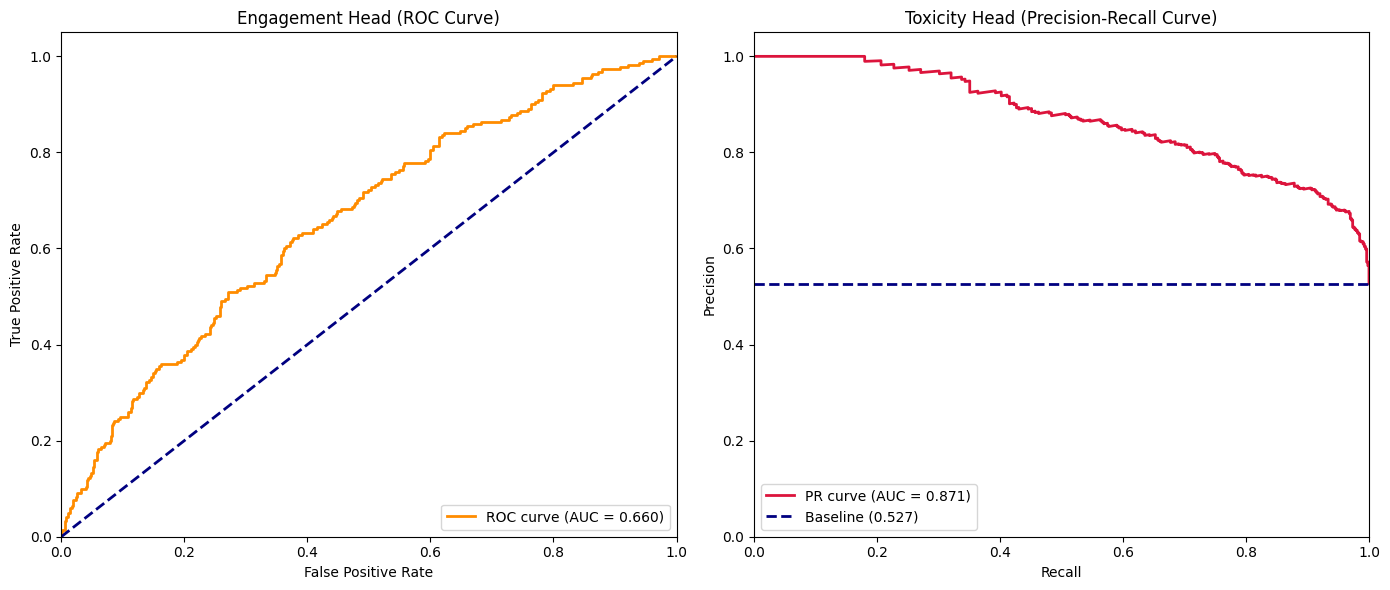

Train Loss: 9.6282, Valid Loss: 10.0285
Saved best model
Epoch 2/5
Batch 125: Loss = 10.2194
Batch 250: Loss = 9.6968
Batch 375: Loss = 9.5996
\n--- Validation Metrics ---
Engagement -> Accuracy: 0.7800 | ROC-AUC: 0.5000
Toxicity   -> Accuracy: 0.6950 | ROC-AUC: 0.7069 | PR-AUC: 0.6998\n


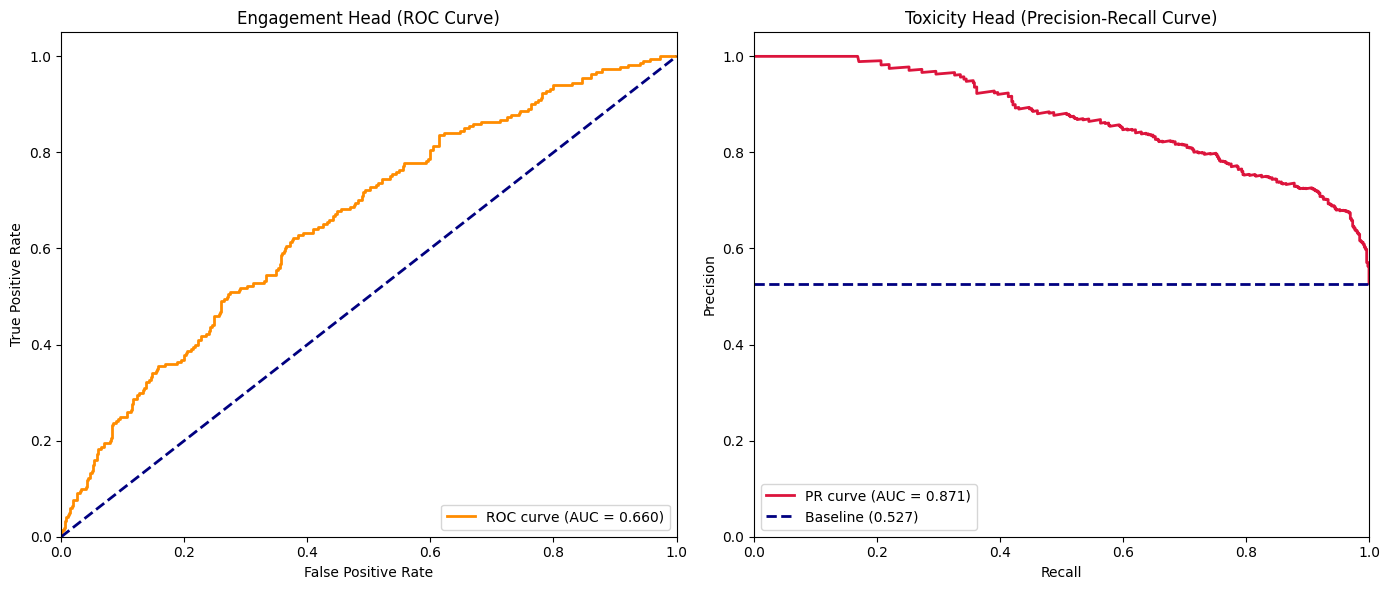

Train Loss: 9.5996, Valid Loss: 10.0251
Saved best model
Epoch 3/5
Batch 125: Loss = 10.2130
Batch 250: Loss = 9.6910
Batch 375: Loss = 9.5943
\n--- Validation Metrics ---
Engagement -> Accuracy: 0.7800 | ROC-AUC: 0.5000
Toxicity   -> Accuracy: 0.6960 | ROC-AUC: 0.7079 | PR-AUC: 0.7007\n


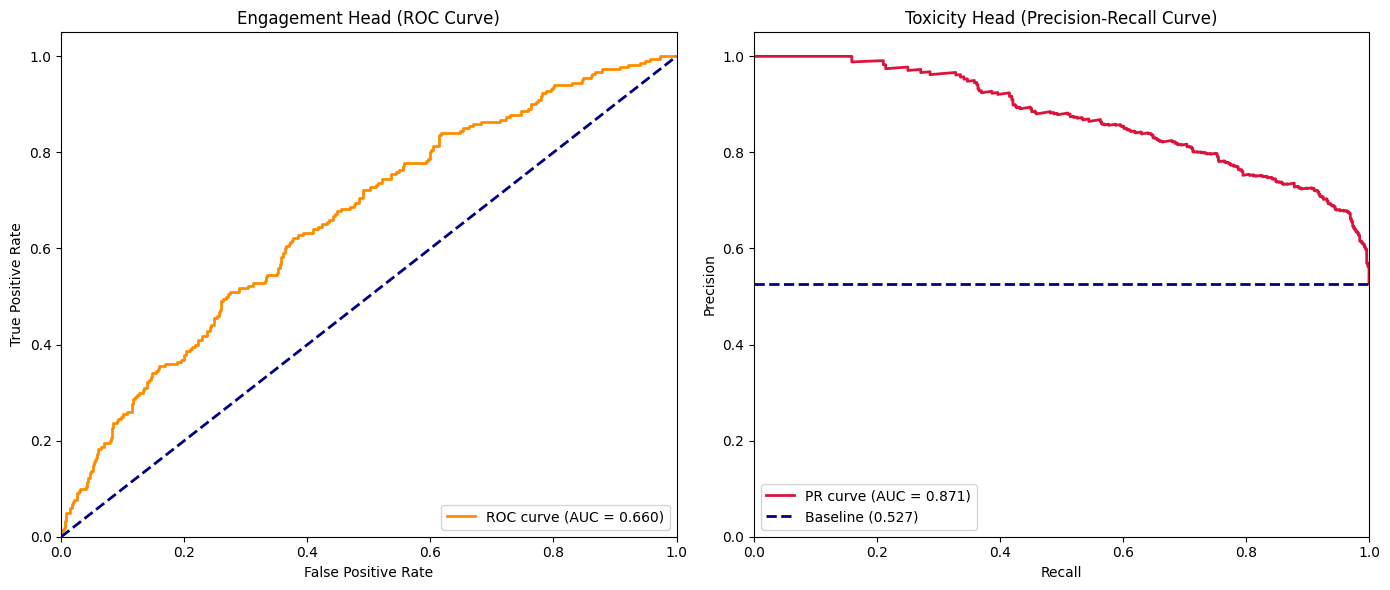

Train Loss: 9.5943, Valid Loss: 10.0226
Saved best model
Epoch 4/5
Batch 125: Loss = 10.2286
Batch 250: Loss = 9.7067
Batch 375: Loss = 9.5683
\n--- Validation Metrics ---
Engagement -> Accuracy: 0.7800 | ROC-AUC: 0.5000
Toxicity   -> Accuracy: 0.6950 | ROC-AUC: 0.7069 | PR-AUC: 0.6998\n


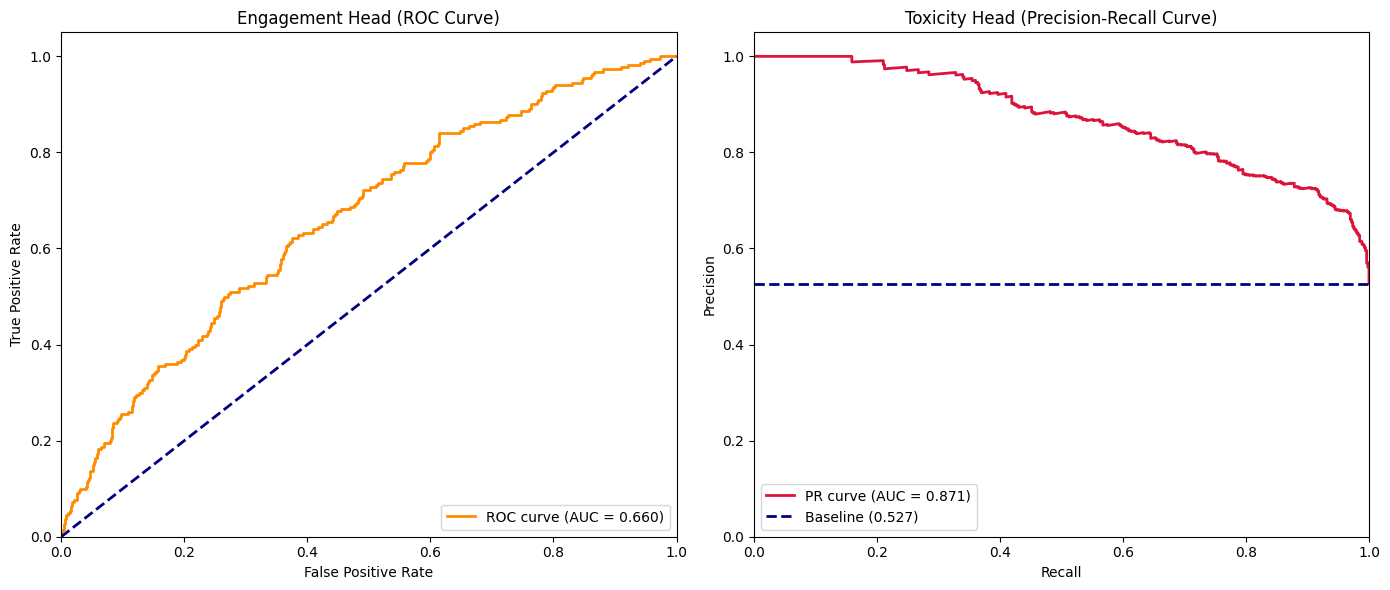

Train Loss: 9.5683, Valid Loss: 10.0207
Saved best model
Epoch 5/5
Batch 125: Loss = 10.2240
Batch 250: Loss = 9.6813
Batch 375: Loss = 9.5641
\n--- Validation Metrics ---
Engagement -> Accuracy: 0.7800 | ROC-AUC: 0.5000
Toxicity   -> Accuracy: 0.6960 | ROC-AUC: 0.7079 | PR-AUC: 0.7007\n


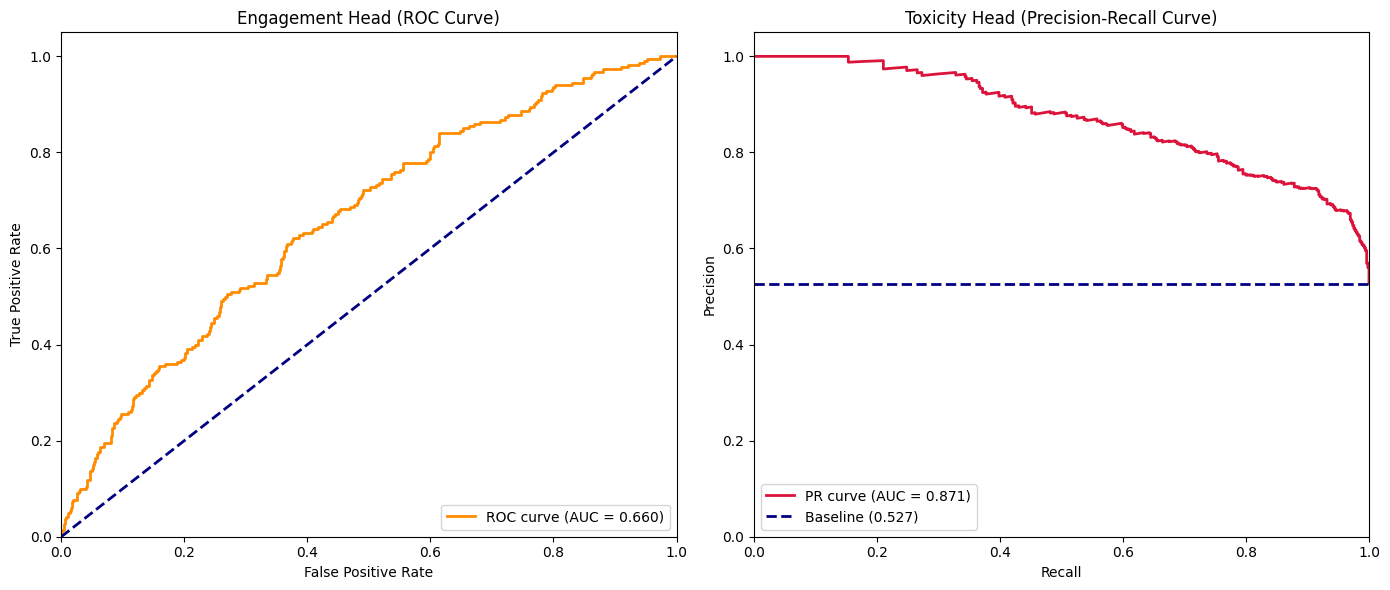

Train Loss: 9.5641, Valid Loss: 10.0195
Saved best model


In [75]:
train(basic_MoE_trained_exp_model, toxicity_train_dataloader, toxicity_valid_dataloader, criterion, optimizer)

In [76]:
inference(test_sentences, basic_MoE_trained_exp_model, embedding_model)

--- QUALITATIVE INFERENCE TEST ---
INPUT TEXT                                                   | ENGAGEMENT PROB | TOXICITY PROB
-----------------------------------------------------------------------------------------------
This is a very standard, polite news article about the ...   | 0.1406          | 0.2736
You are an absolute idiot, delete your account immediat...   | 0.1054          | 0.7462
SHOCKING: 10 ways this celebrity ruined their life! (Mu...   | 0.2394          | 0.5387
I genuinely loved this movie, the cinematography was be...   | 0.2126          | 0.1715
This is a very normal line                                   | 0.1484          | 0.2506
You bitch, I will kill you                                   | 0.1737          | 0.5522
